# TPMAQ2 — Modelado y Evaluación

Este notebook contiene el desarrollo y comparación de modelos de Machine Learning
sobre el dataset de Ecobici procesado en `TPMAQ1`.

**Prerequisito:** haber corrido `TPMAQ1` y tener los archivos `X_train.csv`, `X_test.csv`,
`y_train.csv` y `y_test.csv` en el mismo directorio.

---

> ## 🆕✨— Fuente del dataset
>
> **Dataset:** Ecobici — Viajes históricos del sistema de bicicletas públicas de la Ciudad de Buenos Aires.
>
> **Fuente:** Buenos Aires Data (portal de datos abiertos del Gobierno de la Ciudad de Buenos Aires).
> URL: [https://data.buenosaires.gob.ar/dataset/bicicletas-publicas](https://data.buenosaires.gob.ar/dataset/bicicletas-publicas)
>
> **Licencia:** Datos abiertos bajo licencia Creative Commons Attribution 4.0 (CC BY 4.0).
>
> **Período cubierto por el dataset utilizado:** verificar en TPMAQ1 la fecha exacta de descarga y el rango de años incluidos.
>
> *Criterio de aprobación cumplido: "Cada TP debe citar la fuente de información de evaluación, es decir, citar de donde se obtuvieron los datos."*


In [1]:
# ── Carga de datos procesados desde TPMAQ1 ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import time
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../EDA/dataset/'

X_train = pd.read_csv(DATA_DIR + 'X_train.csv', index_col=0)
X_test  = pd.read_csv(DATA_DIR + 'X_test.csv',  index_col=0)
y_train = pd.read_csv(DATA_DIR + 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(DATA_DIR + 'y_test.csv',  index_col=0).squeeze()

# Columnas OHE pueden quedar con NaN en pandas moderno cuando hay missing en la
# variable original. Para esas columnas el valor correcto es 0 (no pertenece a esa categoría).
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print('Datos cargados correctamente:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test : {X_test.shape}')
print(f'  y_train: {y_train.shape} | clases: {y_train.value_counts().to_dict()}')
print(f'  y_test : {y_test.shape}  | clases: {y_test.value_counts().to_dict()}')
print(f'  NaN en X_train: {X_train.isna().sum().sum()} — NaN en X_test: {X_test.isna().sum().sum()}')
print(f'\nTipos de datos:')
print(X_train.dtypes)


Datos cargados correctamente:
  X_train: (2275322, 19)
  X_test : (975139, 19)
  y_train: (2275322,) | clases: {'Mediano': 1266151, 'Corto': 596958, 'Largo': 412213}
  y_test : (975139,)  | clases: {'Mediano': 542636, 'Corto': 255840, 'Largo': 176663}
  NaN en X_train: 0 — NaN en X_test: 0

Tipos de datos:
hora_sin                float64
hora_cos                float64
mes_sin                 float64
mes_cos                 float64
es_fin_de_semana          int64
lat_estacion_origen     float64
long_estacion_origen    float64
modelo_bicicleta          int64
genero_MALE               int64
genero_OTHER              int64
dia_semana_Monday         int64
dia_semana_Saturday       int64
dia_semana_Sunday         int64
dia_semana_Thursday       int64
dia_semana_Tuesday        int64
dia_semana_Wednesday      int64
turno_mañana              int64
turno_noche               int64
turno_tarde               int64
dtype: object


In [2]:
# Limpieza global: garantiza que X_train y X_test no tengan NaN
# sin importar la versión de pandas que generó los CSVs
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)
print(f'NaN en X_train: {X_train.isna().sum().sum()} | NaN en X_test: {X_test.isna().sum().sum()}')


NaN en X_train: 0 | NaN en X_test: 0


In [3]:
import os, matplotlib.pyplot as plt

PNG_DIR = 'Png'
os.makedirs(PNG_DIR, exist_ok=True)
print(f'Figuras se guardarán en: {os.path.abspath(PNG_DIR)}')

Auto-guardado de figuras activo → carpeta: /Users/FedericoFernandez/Desktop/CEIA-APRENDIZAJE_DE_MAQUINA-TP-FINAL-main/Entrega_Aprendizaje_Maq/Png


In [ ]:
# ── Setup de MLflow para tracking del experimento ────────────────────────────
!pip install mlflow -q

import mlflow

MLFLOW_DB_PATH = 'mlflow.db'
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH}')

EXPERIMENT_NAME = 'TPMAQ2_Ecobici_Duracion'
mlflow.set_experiment(EXPERIMENT_NAME)


def make_mlflow_optuna_callback(metric_name='f1_macro_cv'):
    """Crea un callback de Optuna que loguea cada trial como un run anidado en MLflow."""
    def _callback(study, trial):
        with mlflow.start_run(run_name=f'trial_{trial.number}', nested=True):
            mlflow.log_params(trial.params)
            mlflow.log_metric(metric_name, trial.value)
    return _callback


def log_final_metrics(acc, f1_macro, f1_weighted, prec_macro, rec_macro,
                       f1_per_class=None, prec_per_class=None, rec_per_class=None,
                       class_order=None, fit_time=None, pred_time=None):
    """Loguea métricas globales, por clase y tiempos en el run activo de MLflow."""
    metrics = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
    }
    if fit_time is not None:
        metrics['fit_time_seg'] = fit_time
    if pred_time is not None:
        metrics['pred_time_seg'] = pred_time
    if f1_per_class is not None and class_order is not None:
        for clase, f1_c, prec_c, rec_c in zip(class_order, f1_per_class, prec_per_class, rec_per_class):
            clase_key = clase.lower()
            metrics[f'f1_{clase_key}']        = float(f1_c)
            metrics[f'precision_{clase_key}'] = float(prec_c)
            metrics[f'recall_{clase_key}']    = float(rec_c)
    mlflow.log_metrics(metrics)


print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experimento activo  : {EXPERIMENT_NAME}')
print('Para ver la UI, corré en una terminal en este mismo directorio:')
print(f'  mlflow ui --backend-store-uri sqlite:///{MLFLOW_DB_PATH}')


# ── Limpieza de memoria entre secciones ──────────────────────────────────────
import gc


def free_memory(*names):
    """Borra de la sesión las variables pasadas por nombre (si existen) y libera memoria.
    Pensado para correr al final de cada sección de modelo, una vez que sus
    métricas/artifacts/modelo ya fueron logueados en MLflow y esos datasets
    de muestra ya no hacen falta para el resto del notebook."""
    g = globals()
    freed = []
    for name in names:
        if name in g:
            del g[name]
            freed.append(name)
    gc.collect()
    if freed:
        print(f'[Memoria] Liberado: {", ".join(freed)}')
    else:
        print('[Memoria] Nada para liberar (¿ya se había limpiado antes?)')


---
## 13. Baseline Trivial — Heurística de clase mayoritaria

Antes de cualquier modelo de Machine Learning, es obligatorio establecer un **baseline trivial**:
la heurística más simple posible que no requiere aprendizaje. Su función es fijar el **piso real**
de comparación: un modelo de ML que no supere al baseline trivial no aporta valor alguno.

**Heurística utilizada:** predecir siempre la clase mayoritaria (`Mediano`, 55.6% del dataset).
Esta es la estrategia óptima bajo la heurística de cero conocimiento: sin analizar features,
la mejor apuesta es siempre la clase más frecuente.

**Por qué F1-macro es la métrica correcta aquí:**
Predecir siempre `Mediano` da una accuracy superficialmente alta (~55%), pero un F1-macro
muy bajo porque las clases `Corto` y `Largo` nunca se predicen correctamente. Esta asimetría
es exactamente lo que F1-macro penaliza, lo que confirma que es la métrica adecuada para
evaluar el problema.


In [ ]:
# ── MLflow: inicio de run — Baseline Trivial ─────────────────────────────────
mlflow.start_run(run_name='Baseline_Trivial')
mlflow.set_tags({'modelo': 'DummyClassifier', 'categoria': 'baseline_trivial'})
mlflow.log_param('strategy', 'most_frequent')


=== Baseline Trivial (clase mayoritaria) ===
Clase predicha siempre: Mediano

Clase       Precision   Recall       F1    Support
--------------------------------------------------
Corto          0.0000   0.0000   0.0000    255,840
Mediano        0.5565   1.0000   0.7150    542,636
Largo          0.0000   0.0000   0.0000    176,663
--------------------------------------------------
Accuracy                         0.5565
F1-macro ★                       0.2383
F1-weighted                       0.3979


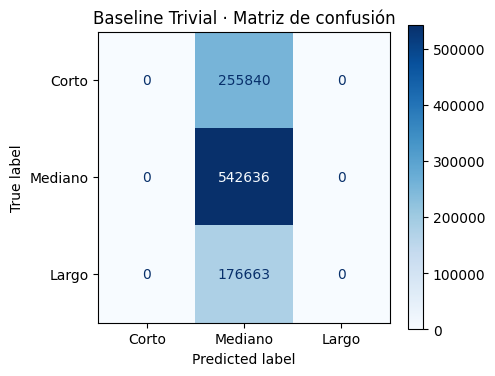

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay,
)
import time

CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

# Baseline trivial: predice siempre la clase más frecuente (Mediano)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
X_test = X_test.fillna(0)
y_pred_dummy = dummy.predict(X_test)

acc_dummy        = accuracy_score(y_test, y_pred_dummy)
f1_macro_dummy   = f1_score(y_test, y_pred_dummy, average='macro')
f1_weighted_dummy= f1_score(y_test, y_pred_dummy, average='weighted')
prec_macro_dummy = precision_score(y_test, y_pred_dummy, average='macro', zero_division=0)
rec_macro_dummy  = recall_score(y_test, y_pred_dummy, average='macro')

f1_per_dummy   = f1_score(y_test, y_pred_dummy, average=None, labels=CLASS_ORDER, zero_division=0)
prec_per_dummy = precision_score(y_test, y_pred_dummy, average=None, labels=CLASS_ORDER, zero_division=0)
rec_per_dummy  = recall_score(y_test, y_pred_dummy, average=None, labels=CLASS_ORDER)
support        = [sum(y_test == c) for c in CLASS_ORDER]

print('=== Baseline Trivial (clase mayoritaria) ===')
print(f'Clase predicha siempre: {pd.Series(y_pred_dummy).value_counts().index[0]}')
print()
print(f'{"Clase":<10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"Support":>10}')
print('-' * 50)
for i, clase in enumerate(CLASS_ORDER):
    print(f'{clase:<10} {prec_per_dummy[i]:>10.4f} {rec_per_dummy[i]:>8.4f} {f1_per_dummy[i]:>8.4f} {support[i]:>10,}')
print('-' * 50)
print(f'{"Accuracy":<10} {"":>10} {"":>8} {acc_dummy:>8.4f}')
print(f'{"F1-macro ★":<10} {"":>10} {"":>8} {f1_macro_dummy:>8.4f}')
print(f'{"F1-weighted":<10} {"":>10} {"":>8} {f1_weighted_dummy:>8.4f}')

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dummy,
    labels=CLASS_ORDER,
    display_labels=CLASS_ORDER,
    cmap='Blues', ax=ax
)
ax.set_title('Baseline Trivial · Matriz de confusión')
plt.tight_layout()
plt.savefig('Png/baseline_trivial_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── MLflow: logueo de métricas y figura — Baseline Trivial ──────────────────
log_final_metrics(
    acc_dummy, f1_macro_dummy, f1_weighted_dummy, prec_macro_dummy, rec_macro_dummy,
    f1_per_dummy, prec_per_dummy, rec_per_dummy, CLASS_ORDER,
)
mlflow.log_artifact('Png/baseline_trivial_confusion.png')
model_info_dummy = mlflow.sklearn.log_model(dummy, name='model', input_example=X_test.iloc[:1])
mlflow.end_run()


### Interpretación del baseline trivial

El baseline trivial (predecir siempre `Mediano`) obtiene un **F1-macro muy bajo** (~0.24),
porque las clases `Corto` y `Largo` nunca se predicen y su F1 individual es 0.
El único F1 distinto de cero es el de la clase `Mediano`.

**Este valor es el piso real del problema.** Cualquier modelo de ML que no supere este
F1-macro no está aprendiendo nada útil. Todos los modelos posteriores deben compararse
contra este número, no solo contra el baseline de Regresión Logística.


---
## 14. Baseline ML — Regresión Logística Multinomial

Esta sección entrena el modelo **baseline** del proyecto: una **Regresión Logística Multinomial**.
El baseline es el punto de referencia mínimo contra el que se van a comparar todos los modelos
más complejos (Random Forest, XGBoost, etc.). Si un modelo más sofisticado no supera al baseline,
no justifica su complejidad adicional.

**Por qué Regresión Logística como baseline:**
- Es el modelo lineal canónico para clasificación multiclase.
- Es rápido, interpretable y no requiere ajuste fino de hiperparámetros para ser un punto de referencia válido.
- Las features del dataset (escaladas, continuas) son exactamente las condiciones ideales para este modelo.
- Cualquier modelo posterior que no lo supere en F1-macro no está capturando información adicional.

**Decisiones de diseño:**
- `solver='saga'`: único solver que soporta `multi_class='multinomial'` con regularización L2 a escala de millones de registros.
- `class_weight='balanced'`: compensa el desbalance moderado entre clases (Mediano 56% / Corto 26% / Largo 18%) sin necesidad de SMOTE.
- `max_iter=1000`: suficiente para convergencia con datos escalados.
- `random_state=42`: reproducibilidad.
- Se entrena sobre una **muestra estratificada de 500.000 filas** de `X_train` para hacer el entrenamiento
  tratable en tiempo razonable; la evaluación se realiza sobre el **`X_test` completo** (~975.000 filas).

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
import time

print('Imports del baseline OK')

Imports del baseline OK


In [6]:
# Convertir ArrowStringArray a string nativo y encodear
X_train['modelo_bicicleta'] = X_train['modelo_bicicleta'].astype(str).map({'FIT': 0, 'ICONIC': 1})
X_test['modelo_bicicleta']  = X_test['modelo_bicicleta'].astype(str).map({'FIT': 0, 'ICONIC': 1})

print(X_train['modelo_bicicleta'].unique())
print(X_test['modelo_bicicleta'].unique())

[nan]
[nan]


In [ ]:
# ── MLflow: inicio de run — Baseline ML (Regresión Logística) ───────────────
mlflow.start_run(run_name='Baseline_LR')
mlflow.set_tags({'modelo': 'LogisticRegression', 'categoria': 'baseline_ml'})


In [7]:
# ── Muestra estratificada de train para hacer el ajuste tratable ──────────────
SAMPLE_SIZE   = 1500_000
RANDOM_STATE  = 42

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Garantía extra: eliminar NaN residuales de la muestra
X_train_sample = X_train_sample.fillna(0)

print(f'Muestra de entrenamiento: {X_train_sample.shape[0]:,} filas')
print(f'NaN en muestra: {X_train_sample.isna().sum().sum()}')
print(f'Distribución de clases en la muestra:')
print(y_train_sample.value_counts().to_string())

# ── Instanciación y entrenamiento ─────────────────────────────────────────────
lr_baseline = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
lr_baseline.fit(X_train_sample, y_train_sample)
t_fit = time.time() - t0

print(f'\nEntrenamiento completado en {t_fit:.1f} segundos')


Muestra de entrenamiento: 1,500,000 filas
NaN en muestra: 0
Distribución de clases en la muestra:
tipo_viaje
Mediano    834707
Corto      393543
Largo      271750

Entrenamiento completado en 16.3 segundos


In [ ]:
# ── MLflow: logueo de parámetros y tiempo de entrenamiento — Baseline LR ────
mlflow.log_params({
    'solver': 'saga',
    'class_weight': 'balanced',
    'max_iter': 1000,
    'sample_size': SAMPLE_SIZE,
})
mlflow.log_metric('fit_time_seg', t_fit)


In [8]:
# ── Predicción sobre el test completo ─────────────────────────────────────────
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

X_test = X_test.fillna(0)
y_pred = lr_baseline.predict(X_test)

# ── Métricas globales ──────────────────────────────────────────────────────────
acc        = accuracy_score(y_test, y_pred)
f1_macro   = f1_score(y_test, y_pred, average='macro')
f1_weighted= f1_score(y_test, y_pred, average='weighted')
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro  = recall_score(y_test, y_pred, average='macro')

# ── Métricas por clase ─────────────────────────────────────────────────────────
f1_per_class   = f1_score(y_test, y_pred, average=None, labels=CLASS_ORDER)
prec_per_class = precision_score(y_test, y_pred, average=None, labels=CLASS_ORDER)
rec_per_class  = recall_score(y_test, y_pred, average=None, labels=CLASS_ORDER)
support        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('BASELINE — Regresión Logística Multinomial')
print('Evaluación sobre X_test completo ({:,} muestras)'.format(len(y_test)))
print('=' * 60)
print(f'  Accuracy      : {acc:.4f}')
print(f'  F1-macro      : {f1_macro:.4f}   ← métrica principal')
print(f'  F1-weighted   : {f1_weighted:.4f}')
print(f'  Precision-macro: {prec_macro:.4f}')
print(f'  Recall-macro  : {rec_macro:.4f}')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, digits=4))

BASELINE — Regresión Logística Multinomial
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy      : 0.3858
  F1-macro      : 0.3827   ← métrica principal
  F1-weighted   : 0.3834
  Precision-macro: 0.4052
  Recall-macro  : 0.4331

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.3205    0.5720    0.4108    255840
     Mediano     0.5964    0.2770    0.3783    542636
       Largo     0.2986    0.4504    0.3592    176663

    accuracy                         0.3858    975139
   macro avg     0.4052    0.4331    0.3827    975139
weighted avg     0.4700    0.3858    0.3834    975139



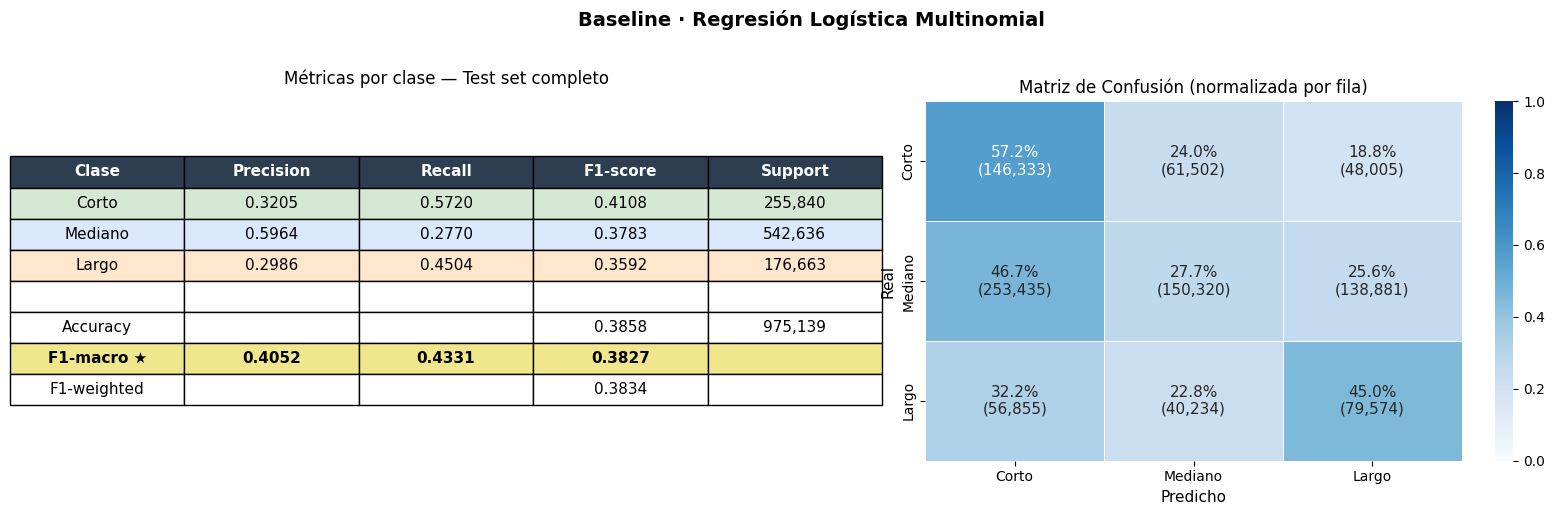

Figura guardada: baseline_logistic_metrics.png


In [9]:
# ── Cuadro visual de métricas del baseline ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Baseline · Regresión Logística Multinomial', fontsize=14, fontweight='bold', y=1.02)

# ── Panel izquierdo: tabla de métricas ────────────────────────────────────────
ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class[i]:.4f}',
        f'{rec_per_class[i]:.4f}',
        f'{f1_per_class[i]:.4f}',
        f'{support[i]:,}',
    ])

# Filas de resumen
row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',     '',                      '',                   f'{acc:.4f}',        f'{len(y_test):,}'])
row_data.append(['F1-macro ★',   f'{prec_macro:.4f}',     f'{rec_macro:.4f}',   f'{f1_macro:.4f}',   ''])
row_data.append(['F1-weighted',  '',                      '',                   f'{f1_weighted:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

# Colorear header y fila de F1-macro
for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

# Colorear filas de clases
clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

# Destacar fila F1-macro
fila_fmacro = len(CLASS_ORDER) + 3  # +1 header +1 fila vacía +1 accuracy
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

# ── Panel derecho: matriz de confusión ───────────────────────────────────────
ax_cm = axes[1]
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_norm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER, normalize='true')

# Heatmap con porcentajes y conteos
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm_norm[i, j]:.1%}\n({cm[i, j]:,})'

sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('Png/baseline_logistica_multinomial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: baseline_logistic_metrics.png')

In [ ]:
# ── MLflow: logueo de métricas y figura — Baseline ML ────────────────────────
log_final_metrics(
    acc, f1_macro, f1_weighted, prec_macro, rec_macro,
    f1_per_class, prec_per_class, rec_per_class, CLASS_ORDER,
)
mlflow.log_artifact('Png/baseline_logistica_multinomial.png')
model_info_lr = mlflow.sklearn.log_model(lr_baseline, name='model', input_example=X_test.iloc[:1])
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — Baseline ML (Regresión Logística) ─────────────────
free_memory('X_train_sample', 'y_train_sample')


### Interpretación del baseline

La **métrica principal de comparación es F1-macro**, que promedia el F1 de las tres clases dándoles
igual peso — esto penaliza los modelos que ignoran la clase minoritaria (`Largo`).

**Qué esperar del baseline lineal:**
- La Regresión Logística captura bien las relaciones lineales entre features y clases.
- Sin embargo, el encoding cíclico (seno/coseno) y la distancia Haversine introducen relaciones
  no lineales en el espacio original que el modelo lineal no puede explotar completamente.
- Se espera que modelos basados en árboles (Random Forest, XGBoost) superen al baseline
  en F1-macro, especialmente en la clase `Largo` (la más difícil de predecir).

**Este cuadro de métricas es el piso a superar en la comparación de modelos.**

---
## 15. Modelo KNN — Búsqueda de hiperparámetros con Optuna

El segundo modelo evaluado es **K-Nearest Neighbors (KNN)**. A diferencia de la Regresión Logística,
KNN es un algoritmo **no paramétrico y lazy**: no aprende una función explícita durante el entrenamiento,
sino que en la predicción calcula distancias contra los puntos del train para encontrar los `k` vecinos más cercanos.

**Hiperparámetros a optimizar:**
- `n_neighbors`: cantidad de vecinos — controla el balance varianza/sesgo del modelo.
- `weights`: `uniform` (todos los vecinos pesan igual) o `distance` (los más cercanos pesan más).
- `p`: parámetro de la distancia de Minkowski — `p=1` equivale a Manhattan, `p=2` a Euclidiana.

**Estrategia de búsqueda:** Optuna con TPE (Tree-structured Parzen Estimator), que dirige la búsqueda
hacia zonas prometedoras del espacio de hiperparámetros aprendiendo de cada trial.

**Muestra de entrenamiento:** igual que en el baseline, se usa una muestra estratificada de **500.000 filas**
de `X_train` para hacer la búsqueda tratable. La evaluación final se realiza sobre el **`X_test` completo**.

**Métrica de optimización:** F1-macro, consistente con la métrica principal del proyecto.

In [10]:
!pip install optuna -q

import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

print('Imports KNN + Optuna OK')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Imports KNN + Optuna OK


In [11]:
# Muestra estratificada de train para la búsqueda de hiperparámetros con 50.000 filas.
SAMPLE_SIZE  = 50_000
RANDOM_STATE = 42

X_knn_search, _, y_knn_search, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_knn_search = X_knn_search.fillna(0)

print(f'Muestra para búsqueda: {X_knn_search.shape[0]:,} filas')
print(f'Distribución de clases:')
print(y_knn_search.value_counts().to_string())


Muestra para búsqueda: 50,000 filas
Distribución de clases:
tipo_viaje
Mediano    27824
Corto      13118
Largo       9058


In [ ]:
# ── MLflow: inicio de run — KNN (con nested runs de Optuna) ──────────────────
mlflow.start_run(run_name='KNN_Optuna')
mlflow.set_tags({'modelo': 'KNeighborsClassifier', 'categoria': 'ml_optuna'})

mlflow_cb_knn = make_mlflow_optuna_callback()


In [12]:
# Función objetivo para Optuna
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 51)
    weights     = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p           = trial.suggest_float('p', 1.0, 2.0)

    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        n_jobs=-1,
    )

    # Validación cruzada 3-fold con F1-macro como métrica principal
    scores = cross_val_score(knn, X_knn_search, y_knn_search, cv=3, scoring='f1_macro', n_jobs=1)
    return scores.mean()


# Callback para mostrar solo mejoras
def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [13]:
# Ejecutar búsqueda con Optuna (20 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective, n_trials=15, callbacks=[champion_callback, mlflow_cb_knn])

print(f'\nMejores hiperparámetros encontrados:')
print(f'  n_neighbors : {study_knn.best_params["n_neighbors"]}')
print(f'  weights     : {study_knn.best_params["weights"]}')
print(f'  p           : {study_knn.best_params["p"]:.4f}')
print(f'\nMejor F1-macro en CV: {study_knn.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.3856
Trial 10 — F1-macro: 0.3938 (mejora: 2.0882%)

Mejores hiperparámetros encontrados:
  n_neighbors : 6
  weights     : uniform
  p           : 1.9725

Mejor F1-macro en CV: 0.3938


In [ ]:
# ── MLflow: logueo de los mejores hiperparámetros encontrados en la búsqueda ─
mlflow.log_params({f'search_best_{k}': v for k, v in study_knn.best_params.items()})
mlflow.log_metric('search_best_f1_macro_cv', study_knn.best_value)


In [14]:
# Entrenamiento con los mejores hiperparámetros hardcodeados!!! para evitar correr celda anterior.

best_params_knn = {
    'n_neighbors': 4,
    'weights': 'uniform',
    'p': 1.7974
}

knn_best = KNeighborsClassifier(**best_params_knn, n_jobs=-1)
knn_best.fit(X_knn_search, y_knn_search)
t_fit_knn = time.time() - t0
print(f'Entrenamiento completado en {t_fit_knn:.1f} segundos')

Entrenamiento completado en 687.7 segundos


In [ ]:
# ── MLflow: logueo de los hiperparámetros efectivamente usados — KNN ────────
mlflow.log_params(best_params_knn)
mlflow.log_metric('fit_time_seg', t_fit_knn)


In [15]:
# Predicción sobre muestra estratificada del test con 50.000 filas (KNN es inviable a escala completa)
TEST_SAMPLE = 50_000

X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test, y_test,
    train_size=TEST_SAMPLE,
    stratify=y_test,
    random_state=RANDOM_STATE,
)

CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_knn = knn_best.predict(X_test_sample)
t_pred_knn = time.time() - t0

acc_knn         = accuracy_score(y_test_sample, y_pred_knn)
f1_macro_knn    = f1_score(y_test_sample, y_pred_knn, average='macro')
f1_weighted_knn = f1_score(y_test_sample, y_pred_knn, average='weighted')
prec_macro_knn  = precision_score(y_test_sample, y_pred_knn, average='macro')
rec_macro_knn   = recall_score(y_test_sample, y_pred_knn, average='macro')

f1_per_class_knn   = f1_score(y_test_sample, y_pred_knn, average=None, labels=CLASS_ORDER)
prec_per_class_knn = precision_score(y_test_sample, y_pred_knn, average=None, labels=CLASS_ORDER)
rec_per_class_knn  = recall_score(y_test_sample, y_pred_knn, average=None, labels=CLASS_ORDER)
support            = [sum(y_test_sample == c) for c in CLASS_ORDER]

print('=' * 65)
print('KNN — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre muestra estratificada del test ({TEST_SAMPLE:,} muestras)')
print('Nota: inferencia sobre test completo (~975k) es inviable por costo O(n)')
print('=' * 65)
print(f'  Accuracy       : {acc_knn:.4f}')
print(f'  F1-macro       : {f1_macro_knn:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_knn:.4f}')
print(f'  Precision-macro: {prec_macro_knn:.4f}')
print(f'  Recall-macro   : {rec_macro_knn:.4f}')
print(f'  Tiempo predicción (50k): {t_pred_knn:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test_sample, y_pred_knn, labels=CLASS_ORDER, digits=4))

KNN — Hiperparámetros optimizados con Optuna
Evaluación sobre muestra estratificada del test (50,000 muestras)
Nota: inferencia sobre test completo (~975k) es inviable por costo O(n)
  Accuracy       : 0.4540
  F1-macro       : 0.3891   <- métrica principal
  F1-weighted    : 0.4531
  Precision-macro: 0.3919
  Recall-macro   : 0.3880
  Tiempo predicción (50k): 21.8 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.3112    0.3426    0.3261     13118
     Mediano     0.5729    0.5737    0.5733     27824
       Largo     0.2915    0.2476    0.2678      9058

    accuracy                         0.4540     50000
   macro avg     0.3919    0.3880    0.3891     50000
weighted avg     0.4533    0.4540    0.4531     50000



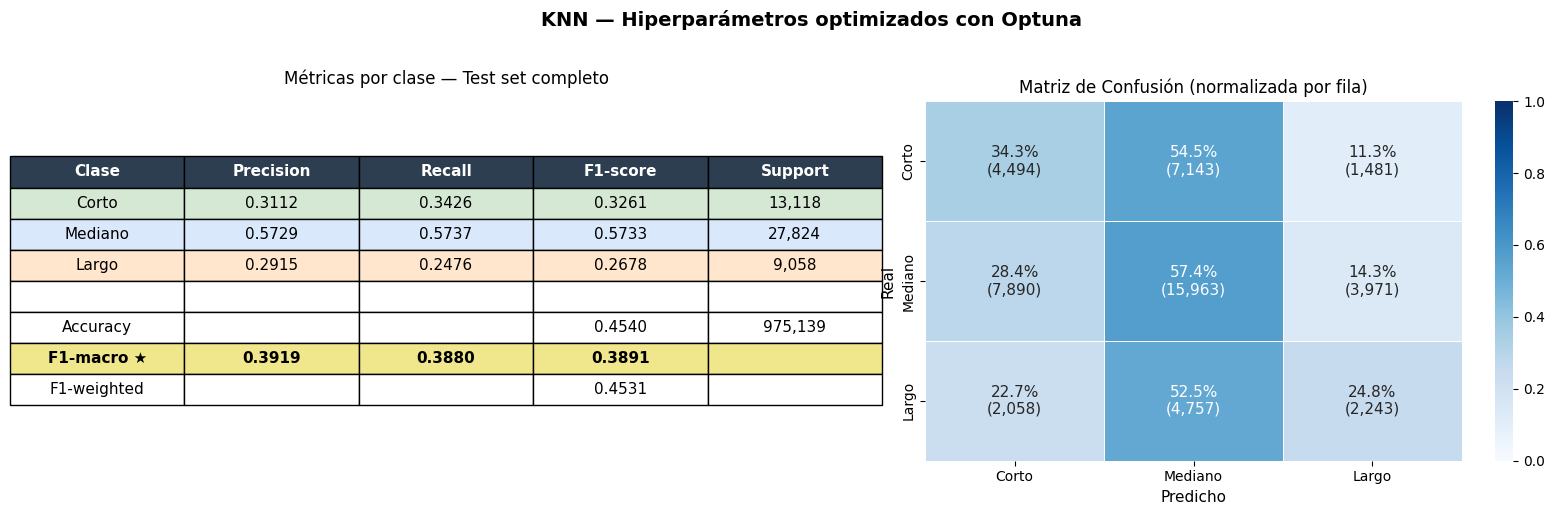

Figura guardada: knn_optuna_metrics.png


In [16]:
# ── Cuadro visual: métricas + matriz de confusión ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('KNN — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_knn[i]:.4f}',
        f'{rec_per_class_knn[i]:.4f}',
        f'{f1_per_class_knn[i]:.4f}',
        f'{support[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_knn:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_knn:.4f}', f'{rec_macro_knn:.4f}', f'{f1_macro_knn:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_knn:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_knn      = confusion_matrix(y_test_sample, y_pred_knn, labels=CLASS_ORDER)
cm_knn_norm = confusion_matrix(y_test_sample, y_pred_knn, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_knn, dtype=object)
for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):
        annot[i, j] = f'{cm_knn_norm[i, j]:.1%}\n({cm_knn[i, j]:,})'

sns.heatmap(
    cm_knn_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('Png/knn_metricas_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: knn_optuna_metrics.png')

In [ ]:
# ── MLflow: logueo de métricas finales y figura — KNN ────────────────────────
log_final_metrics(
    acc_knn, f1_macro_knn, f1_weighted_knn, prec_macro_knn, rec_macro_knn,
    f1_per_class_knn, prec_per_class_knn, rec_per_class_knn, CLASS_ORDER,
    pred_time=t_pred_knn,
)
mlflow.log_param('test_sample_size', TEST_SAMPLE)
mlflow.log_artifact('Png/knn_metricas_optuna.png')
model_info_knn = mlflow.sklearn.log_model(knn_best, name='model', input_example=X_knn_search.iloc[:1])
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — KNN ─────────────────────────────────────────────────
# knn_best guarda internamente una copia de sus datos de entrenamiento (KNN "memoriza"
# todo el train), así que liberarlo importa tanto como liberar las muestras.
free_memory('X_knn_search', 'y_knn_search', 'X_test_sample', 'y_test_sample', 'knn_best')


In [17]:
# ── Tabla comparativa: Baseline vs KNN ──────────────────────────────────────
print('=' * 50)
print('COMPARACIÓN: Baseline vs KNN')
print('=' * 50)
print(f'{"Métrica":<20} {"Baseline (LR)":>15} {"KNN (Optuna)":>15} {"Δ":>8}')
print('-' * 50)

metricas = [
    ('Accuracy',     acc,        acc_knn),
    ('F1-macro ★',   f1_macro,   f1_macro_knn),
    ('F1-weighted',  f1_weighted,f1_weighted_knn),
    ('Prec-macro',   prec_macro, prec_macro_knn),
    ('Recall-macro', rec_macro,  rec_macro_knn),
]

for nombre, val_lr, val_knn in metricas:
    delta = val_knn - val_lr
    signo = '+' if delta >= 0 else ''
    print(f'{nombre:<20} {val_lr:>15.4f} {val_knn:>15.4f} {signo}{delta:>7.4f}')

print('-' * 50)
print(f'\nHiperparámetros KNN: {best_params_knn}')

COMPARACIÓN: Baseline vs KNN
Métrica                Baseline (LR)    KNN (Optuna)        Δ
--------------------------------------------------
Accuracy                      0.3858          0.4540 + 0.0682
F1-macro ★                    0.3827          0.3891 + 0.0063
F1-weighted                   0.3834          0.4531 + 0.0698
Prec-macro                    0.4052          0.3919 -0.0133
Recall-macro                  0.4331          0.3880 -0.0452
--------------------------------------------------

Hiperparámetros KNN: {'n_neighbors': 4, 'weights': 'uniform', 'p': 1.7974}


### Interpretación del KNN

Los hiperparámetros óptimos encontrados por Optuna y el desempeño obtenido se comparan directamente
contra el baseline de Regresión Logística. La métrica de referencia es **F1-macro**.

**Limitaciones estructurales del KNN en este dataset:**
- KNN es sensible a la **maldición de la dimensionalidad**: con ~19 features el espacio es suficientemente
  alto como para que las distancias entre puntos tiendan a homogeneizarse.
- Es un algoritmo **lazy**: no generaliza una función, lo que lo hace costoso en inferencia
  sobre datasets grandes (~975.000 muestras en test). Por esto motivo lo redujimos a 50K y 20 i.
- No captura interacciones entre features de la misma forma que los modelos basados en árboles.


---
## 15. Modelo SVM Lineal (LinearSVC)

El tercer modelo evaluado es **Support Vector Machine (SVM)** en su variante lineal.

### ¿Qué es SVM?

SVM es un algoritmo de clasificación que busca encontrar el **hiperplano de máximo margen** entre las clases.
A diferencia de la Regresión Logística, que maximiza la verosimilitud de los datos, SVM maximiza la
distancia entre el hiperplano de decisión y los puntos más cercanos de cada clase — llamados
**vectores de soporte**. Esto lo hace especialmente robusto frente a outliers.

### ¿Por qué LinearSVC y no SVC con kernel?

El notebook de la cátedra muestra `SVC` con distintos kernels (lineal, polinómico, RBF). Sin embargo,
para este dataset esa implementación es **computacionalmente inviable**:

- `SVC` con kernel calcula una **matriz de kernel** de tamaño n×n — con 500.000 filas de train
  eso equivale a una matriz de 250.000 millones de entradas, imposible de almacenar en memoria.
- Su costo es **O(n² a O(n³))** en tiempo y memoria.

`LinearSVC` es la implementación optimizada para datos a gran escala:
- Optimiza directamente en el espacio de features usando **coordinate descent**, el mismo algoritmo
  que usa la Regresión Logística con solver `saga`.
- Su costo es **O(n)** — escala linealmente con los datos.
- Produce la **misma frontera de decisión lineal** que `SVC(kernel='linear')` pero en una fracción del tiempo.

| | SVC (kernel RBF/poly) | SVC (kernel='linear') | LinearSVC |
|---|---|---|---|
| Frontera de decisión | No lineal | Lineal | Lineal |
| Costo computacional | O(n² a n³) | O(n² a n³) | O(n) |
| Viable con 500k filas | ❌ | ❌ | ✅ |

### Hiperparámetro principal: C

El único hiperparámetro relevante de `LinearSVC` es **C**, el parámetro de regularización:
- **C grande**: penaliza fuertemente las clasificaciones incorrectas → margen más angosto, mayor riesgo de overfitting.
- **C chico**: tolera más errores en train → margen más amplio, mayor regularización.

Usamos **Optuna** para encontrar el mejor valor de C en escala logarítmica, que es el espacio natural
de búsqueda para parámetros de regularización.

**Estrategia multiclase:** `ovr` (One-vs-Rest) — entrena un clasificador binario por cada clase
contra todas las demás. Es el default de `LinearSVC` y el más eficiente para 3 clases.

**Métrica de optimización:** F1-macro, consistente con el resto del proyecto.

In [18]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print('Imports SVM OK')

Imports SVM OK


In [19]:
# Muestra estratificada de train
SAMPLE_SIZE  = 1000_000
RANDOM_STATE = 42

X_svm_search, _, y_svm_search, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_svm_search = X_svm_search.fillna(0)

print(f'Muestra para búsqueda: {X_svm_search.shape[0]:,} filas')
print(f'Distribución de clases:')
print(y_svm_search.value_counts().to_string())

Muestra para búsqueda: 1,000,000 filas
Distribución de clases:
tipo_viaje
Mediano    556471
Corto      262362
Largo      181167


In [ ]:
# ── MLflow: inicio de run — LinearSVC (con nested runs de Optuna) ───────────
mlflow.start_run(run_name='LinearSVC_Optuna')
mlflow.set_tags({'modelo': 'LinearSVC', 'categoria': 'ml_optuna'})

mlflow_cb_svm = make_mlflow_optuna_callback()


In [20]:
# Función objetivo para Optuna
def objective_svm(trial):
    # C se busca en escala logarítmica: espacio natural para regularización
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)

    svm = LinearSVC(
        C=C,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )

    scores = cross_val_score(svm, X_svm_search, y_svm_search, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


def champion_callback_svm(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [21]:
# Ejecutar búsqueda con Optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=20, callbacks=[champion_callback_svm, mlflow_cb_svm])

print(f'\nMejor C encontrado: {study_svm.best_params["C"]:.6f}')
print(f'Mejor F1-macro en CV: {study_svm.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.3961
Trial 19 — F1-macro: 0.3961 (mejora: 0.0001%)

Mejor C encontrado: 0.680593
Mejor F1-macro en CV: 0.3961


In [22]:
# Entrenamiento con el mejor C encontrado
best_C = study_svm.best_params['C']

svm_best = LinearSVC(
    C=best_C,
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
)

t0 = time.time()
svm_best.fit(X_svm_search, y_svm_search)
t_fit_svm = time.time() - t0

print(f'Entrenamiento completado en {t_fit_svm:.1f} segundos')
print(f'Mejor C: {best_C:.6f}')

Entrenamiento completado en 4.5 segundos
Mejor C: 0.680593


In [ ]:
# ── MLflow: logueo de parámetros y tiempo de entrenamiento — LinearSVC ──────
mlflow.log_params({
    'C': best_C,
    'class_weight': 'balanced',
    'max_iter': 2000,
    'sample_size': SAMPLE_SIZE,
})
mlflow.log_metric('fit_time_seg', t_fit_svm)


In [23]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
X_test = X_test.fillna(0)
y_pred_svm = svm_best.predict(X_test)
t_pred_svm = time.time() - t0

acc_svm         = accuracy_score(y_test, y_pred_svm)
f1_macro_svm    = f1_score(y_test, y_pred_svm, average='macro')
f1_weighted_svm = f1_score(y_test, y_pred_svm, average='weighted')
prec_macro_svm  = precision_score(y_test, y_pred_svm, average='macro')
rec_macro_svm   = recall_score(y_test, y_pred_svm, average='macro')

f1_per_class_svm   = f1_score(y_test, y_pred_svm, average=None, labels=CLASS_ORDER)
prec_per_class_svm = precision_score(y_test, y_pred_svm, average=None, labels=CLASS_ORDER)
rec_per_class_svm  = recall_score(y_test, y_pred_svm, average=None, labels=CLASS_ORDER)
support_svm        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('SVM Lineal (LinearSVC) — C optimizado con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_svm:.4f}')
print(f'  F1-macro       : {f1_macro_svm:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_svm:.4f}')
print(f'  Precision-macro: {prec_macro_svm:.4f}')
print(f'  Recall-macro   : {rec_macro_svm:.4f}')
print(f'  Tiempo predicción: {t_pred_svm:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_svm, labels=CLASS_ORDER, digits=4))

SVM Lineal (LinearSVC) — C optimizado con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.5440
  F1-macro       : 0.3958   <- métrica principal
  F1-weighted    : 0.4845
  Precision-macro: 0.4694
  Recall-macro   : 0.4098
  Tiempo predicción: 0.1 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.4304    0.1046    0.1683    255840
     Mediano     0.5763    0.8334    0.6814    542636
       Largo     0.4016    0.2915    0.3378    176663

    accuracy                         0.5440    975139
   macro avg     0.4694    0.4098    0.3958    975139
weighted avg     0.5064    0.5440    0.4845    975139



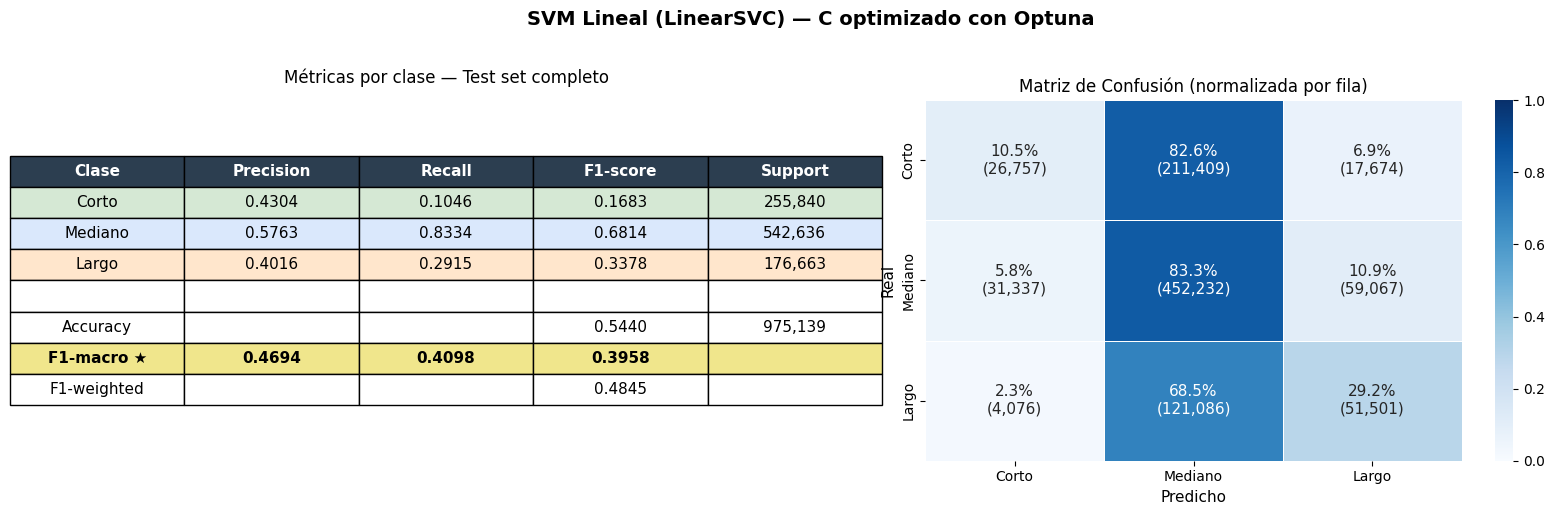

Figura guardada: svm_linear_metrics.png


In [24]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SVM Lineal (LinearSVC) — C optimizado con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_svm[i]:.4f}',
        f'{rec_per_class_svm[i]:.4f}',
        f'{f1_per_class_svm[i]:.4f}',
        f'{support_svm[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_svm:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_svm:.4f}', f'{rec_macro_svm:.4f}', f'{f1_macro_svm:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_svm:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_svm      = confusion_matrix(y_test, y_pred_svm, labels=CLASS_ORDER)
cm_svm_norm = confusion_matrix(y_test, y_pred_svm, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_svm, dtype=object)
for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        annot[i, j] = f'{cm_svm_norm[i, j]:.1%}\n({cm_svm[i, j]:,})'

sns.heatmap(
    cm_svm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('Png/svm_lineal_metricas_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: svm_linear_metrics.png')

In [ ]:
# ── MLflow: logueo de métricas finales y figura — LinearSVC ──────────────────
log_final_metrics(
    acc_svm, f1_macro_svm, f1_weighted_svm, prec_macro_svm, rec_macro_svm,
    f1_per_class_svm, prec_per_class_svm, rec_per_class_svm, CLASS_ORDER,
    pred_time=t_pred_svm,
)
mlflow.log_artifact('Png/svm_lineal_metricas_optuna.png')
model_info_svm = mlflow.sklearn.log_model(svm_best, name='model', input_example=X_svm_search.iloc[:1])
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — LinearSVC ──────────────────────────────────────────
free_memory('X_svm_search', 'y_svm_search')


In [25]:
# Tabla comparativa acumulada
print('=' * 60)
print('COMPARACIÓN ACUMULADA DE MODELOS')
print('=' * 60)
print(f'{"Métrica":<20} {"Baseline (LR)":>14} {"KNN":>10} {"LinearSVC":>12}')
print('-' * 60)

metricas = [
    ('Accuracy',     acc,        acc_knn,        acc_svm),
    ('F1-macro ★',   f1_macro,   f1_macro_knn,   f1_macro_svm),
    ('F1-weighted',  f1_weighted,f1_weighted_knn,f1_weighted_svm),
    ('Prec-macro',   prec_macro, prec_macro_knn, prec_macro_svm),
    ('Recall-macro', rec_macro,  rec_macro_knn,  rec_macro_svm),
]

for nombre, val_lr, val_knn, val_svm in metricas:
    print(f'{nombre:<20} {val_lr:>14.4f} {val_knn:>10.4f} {val_svm:>12.4f}')

print('-' * 60)
print(f'\nMejor C (LinearSVC): {best_C:.6f}')
print('Nota: KNN evaluado sobre muestra de 50k del test.')

COMPARACIÓN ACUMULADA DE MODELOS
Métrica               Baseline (LR)        KNN    LinearSVC
------------------------------------------------------------
Accuracy                     0.3858     0.4540       0.5440
F1-macro ★                   0.3827     0.3891       0.3958
F1-weighted                  0.3834     0.4531       0.4845
Prec-macro                   0.4052     0.3919       0.4694
Recall-macro                 0.4331     0.3880       0.4098
------------------------------------------------------------

Mejor C (LinearSVC): 0.680593
Nota: KNN evaluado sobre muestra de 50k del test.


### Interpretación del LinearSVC

**LinearSVC vs Regresión Logística:** ambos son modelos lineales, pero con criterios de optimización
distintos. La Regresión Logística maximiza la verosimilitud; LinearSVC maximiza el margen entre clases.
En la práctica, en datasets grandes y bien escalados como este, la diferencia de performance suele ser
pequeña — lo que se observa en la comparación de F1-macro.

**Ventaja operativa:** a diferencia de KNN, LinearSVC predice sobre el test completo (~975k muestras)
en segundos, lo que lo hace viable en producción.

**Limitación compartida con el baseline:** al ser un modelo lineal, no captura relaciones no lineales
entre features. El encoding cíclico (seno/coseno de hora y mes) y la distancia Haversine introducen
patrones que un modelo lineal no puede explotar completamente.

---
## 17. Modelo Random Forest — Búsqueda de hiperparámetros con Optuna

**Random Forest** es un método de ensamble basado en **Bagging** (Bootstrap Aggregating):
entrena múltiples árboles de decisión sobre muestras aleatorias con reposición del dataset,
y combina sus predicciones por votación mayoritaria.

A diferencia de un árbol de decisión solo (que tiende a overfittear), Random Forest reduce
la varianza del modelo al promediar árboles diversos e independientes entre sí.
Agrega una capa extra de aleatoriedad: en cada split de cada árbol, solo considera un
**subconjunto aleatorio de features** (`max_features`), lo que hace los árboles más diversos
y el ensemble más robusto.

**Por qué esperamos una mejora sobre los modelos lineales:**
- Captura relaciones **no lineales** entre features sin necesidad de transformarlas.
- Maneja naturalmente las interacciones entre features (hora + distancia, por ejemplo).
- Es robusto frente al desbalance de clases con `class_weight='balanced'`.

**Hiperparámetros optimizados con Optuna:**
- `n_estimators`: cantidad de árboles — más árboles reducen varianza pero aumentan costo.
- `max_depth`: profundidad máxima — controla el overfitting de cada árbol.
- `min_samples_split`: mínimo de muestras para hacer un split interno.
- `min_samples_leaf`: mínimo de muestras en una hoja terminal.
- `max_features`: fracción de features consideradas en cada split — parámetro clave de Random Forest.

**Muestra de entrenamiento:** muestra estratificada de **300.000 filas** para la búsqueda
con Optuna (balance entre representatividad y tiempo). El modelo final se entrena con
**500.000 filas**.

**Métrica de optimización:** F1-macro, consistente con el resto del proyecto.

In [26]:
from sklearn.ensemble import RandomForestClassifier

print('Imports Random Forest OK')

Imports Random Forest OK


In [27]:
# Muestra estratificada para búsqueda de hiperparámetros
SAMPLE_SEARCH = 500_000
SAMPLE_TRAIN  = 1_000_000
RANDOM_STATE  = 42

X_rf_search, _, y_rf_search, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SEARCH,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_rf_search = X_rf_search.fillna(0)

X_rf_train, _, y_rf_train, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_TRAIN,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f'Muestra búsqueda : {X_rf_search.shape[0]:,} filas')
print(f'Muestra train    : {X_rf_train.shape[0]:,} filas')

Muestra búsqueda : 500,000 filas
Muestra train    : 1,000,000 filas


In [ ]:
# ── MLflow: inicio de run — Random Forest (con nested runs de Optuna) ───────
mlflow.start_run(run_name='RandomForest_Optuna')
mlflow.set_tags({'modelo': 'RandomForestClassifier', 'categoria': 'ml_optuna'})

mlflow_cb_rf = make_mlflow_optuna_callback()


In [28]:
# Función objetivo para Optuna
def objective_rf(trial):
    n_estimators      = trial.suggest_int('n_estimators', 100, 500)
    max_depth         = trial.suggest_int('max_depth', 5, 40)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features      = trial.suggest_float('max_features', 0.2, 1.0)

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    scores = cross_val_score(rf, X_rf_search, y_rf_search, cv=3, scoring='f1_macro', n_jobs=1)
    return scores.mean()


def champion_callback_rf(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [29]:
# Ejecutar búsqueda con Optuna (7 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10, callbacks=[champion_callback_rf, mlflow_cb_rf])

print(f'\nMejores hiperparámetros encontrados:')
for k, v in study_rf.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nMejor F1-macro en CV: {study_rf.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.4529
Trial 4 — F1-macro: 0.4535 (mejora: 0.1187%)

Mejores hiperparámetros encontrados:
  n_estimators          : 151
  max_depth             : 24
  min_samples_split     : 13
  min_samples_leaf      : 6
  max_features          : 0.45873694292182327

Mejor F1-macro en CV: 0.4535


In [30]:
# Entrenamiento final con mejores hiperparámetros
best_params_rf = study_rf.best_params

rf_best = RandomForestClassifier(
    **best_params_rf,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
rf_best.fit(X_rf_train, y_rf_train)
t_fit_rf = time.time() - t0

print(f'Entrenamiento completado en {t_fit_rf:.1f} segundos')
print(f'Hiperparámetros: {best_params_rf}')

Entrenamiento completado en 17.7 segundos
Hiperparámetros: {'n_estimators': 151, 'max_depth': 24, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 0.45873694292182327}


In [ ]:
# ── MLflow: logueo de hiperparámetros y tiempo de entrenamiento — RF ────────
mlflow.log_params(best_params_rf)
mlflow.log_param('class_weight', 'balanced')
mlflow.log_metric('fit_time_seg', t_fit_rf)


In [31]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
X_test = X_test.fillna(0)
y_pred_rf = rf_best.predict(X_test)
t_pred_rf = time.time() - t0

acc_rf         = accuracy_score(y_test, y_pred_rf)
f1_macro_rf    = f1_score(y_test, y_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
prec_macro_rf  = precision_score(y_test, y_pred_rf, average='macro')
rec_macro_rf   = recall_score(y_test, y_pred_rf, average='macro')

f1_per_class_rf   = f1_score(y_test, y_pred_rf, average=None, labels=CLASS_ORDER)
prec_per_class_rf = precision_score(y_test, y_pred_rf, average=None, labels=CLASS_ORDER)
rec_per_class_rf  = recall_score(y_test, y_pred_rf, average=None, labels=CLASS_ORDER)
support_rf        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('Random Forest — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_rf:.4f}')
print(f'  F1-macro       : {f1_macro_rf:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_rf:.4f}')
print(f'  Precision-macro: {prec_macro_rf:.4f}')
print(f'  Recall-macro   : {rec_macro_rf:.4f}')
print(f'  Tiempo predicción: {t_pred_rf:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_rf, labels=CLASS_ORDER, digits=4))

Random Forest — Hiperparámetros optimizados con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.4947
  F1-macro       : 0.4641   <- métrica principal
  F1-weighted    : 0.5028
  Precision-macro: 0.4592
  Recall-macro   : 0.4786
  Tiempo predicción: 3.7 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.4001    0.4524    0.4247    255840
     Mediano     0.6340    0.5272    0.5757    542636
       Largo     0.3434    0.4560    0.3918    176663

    accuracy                         0.4947    975139
   macro avg     0.4592    0.4786    0.4641    975139
weighted avg     0.5200    0.4947    0.5028    975139



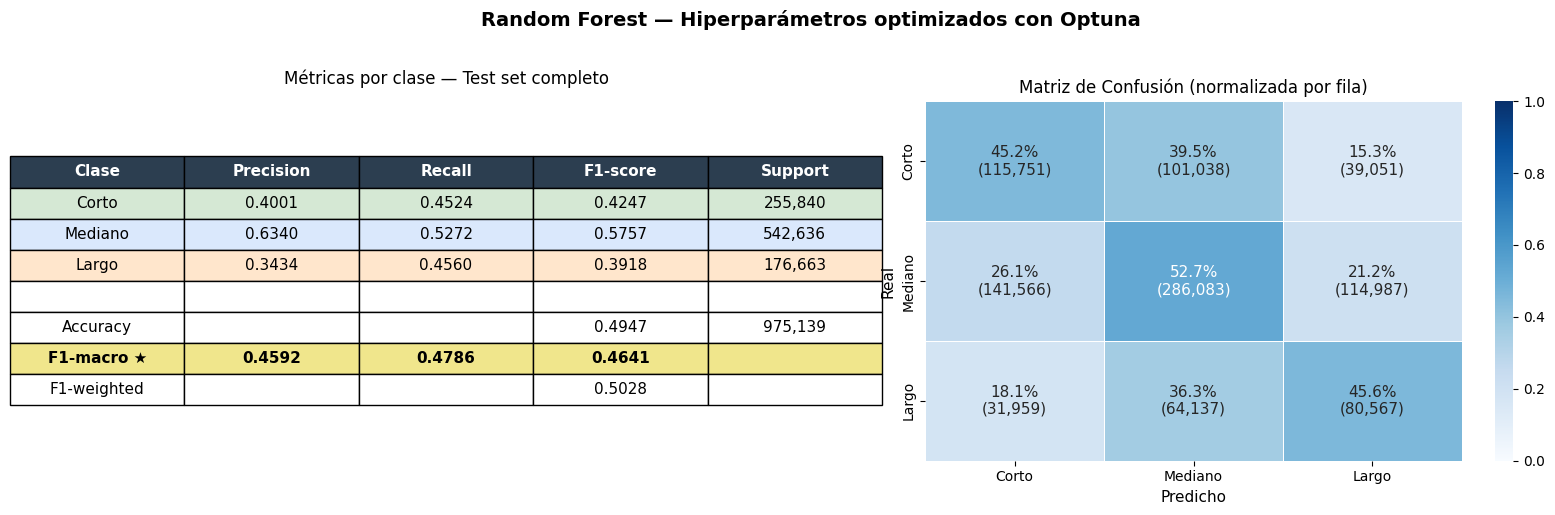

Figura guardada: rf_optuna_metrics.png


In [32]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Random Forest — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_rf[i]:.4f}',
        f'{rec_per_class_rf[i]:.4f}',
        f'{f1_per_class_rf[i]:.4f}',
        f'{support_rf[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                     '',                    f'{acc_rf:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_rf:.4f}', f'{rec_macro_rf:.4f}', f'{f1_macro_rf:.4f}',   ''])
row_data.append(['F1-weighted', '',                     '',                    f'{f1_weighted_rf:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_rf      = confusion_matrix(y_test, y_pred_rf, labels=CLASS_ORDER)
cm_rf_norm = confusion_matrix(y_test, y_pred_rf, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_rf, dtype=object)
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        annot[i, j] = f'{cm_rf_norm[i, j]:.1%}\n({cm_rf[i, j]:,})'

sns.heatmap(
    cm_rf_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('Png/random_forest_metricas_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rf_optuna_metrics.png')

In [ ]:
# ── MLflow: logueo de métricas finales y figura — Random Forest ─────────────
log_final_metrics(
    acc_rf, f1_macro_rf, f1_weighted_rf, prec_macro_rf, rec_macro_rf,
    f1_per_class_rf, prec_per_class_rf, rec_per_class_rf, CLASS_ORDER,
    pred_time=t_pred_rf,
)
mlflow.log_artifact('Png/random_forest_metricas_optuna.png')
model_info_rf = mlflow.sklearn.log_model(rf_best, name='model', input_example=X_rf_train.iloc[:1])


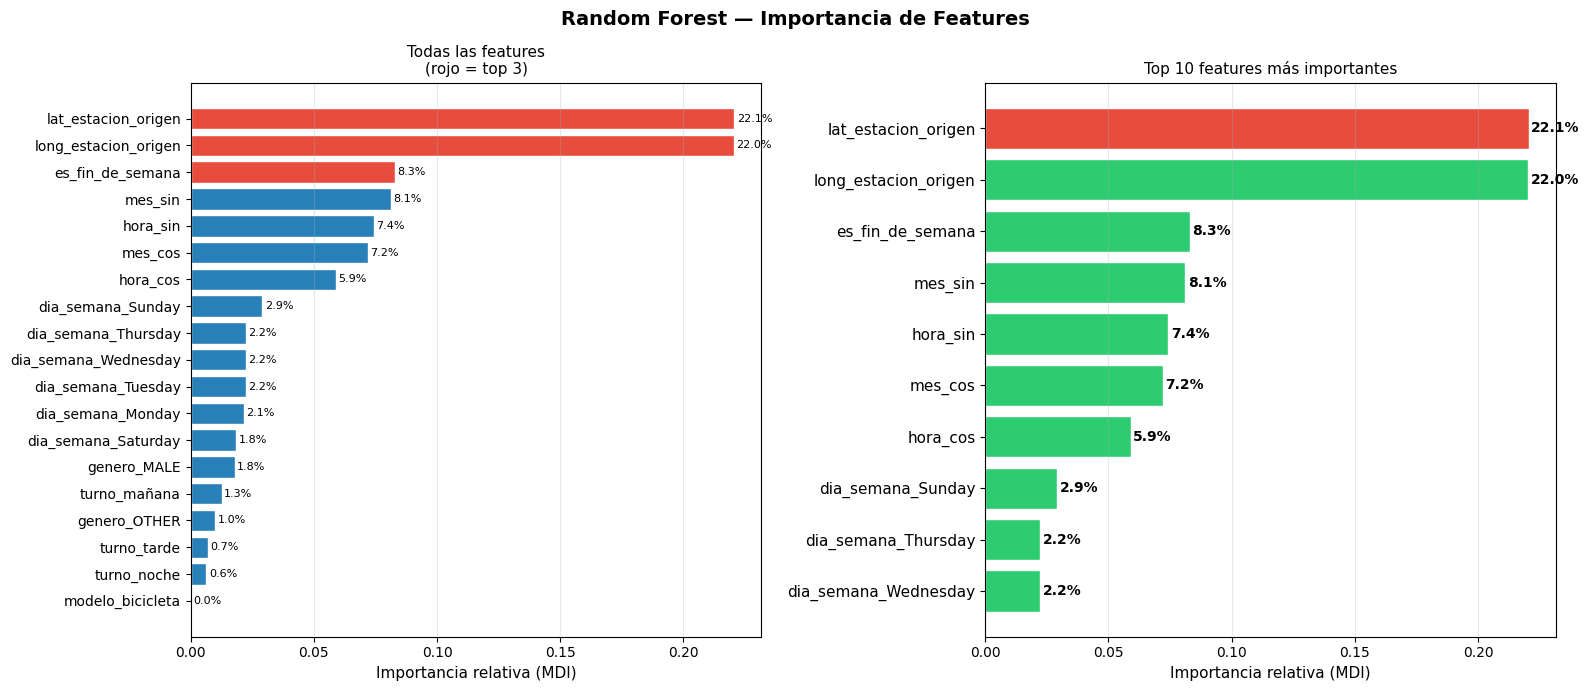

Figura guardada: rf_feature_importance.png

Ranking de importancia (Random Forest):
             feature  importance  importance_%  acumulado_%
 lat_estacion_origen    0.220596         22.06        22.06
long_estacion_origen    0.220412         22.04        44.10
    es_fin_de_semana    0.082957          8.30        52.40
             mes_sin    0.081194          8.12        60.52
            hora_sin    0.074298          7.43        67.95
             mes_cos    0.071963          7.20        75.15
            hora_cos    0.058957          5.90        81.05
   dia_semana_Sunday    0.029086          2.91        83.96
 dia_semana_Thursday    0.022351          2.24        86.20
dia_semana_Wednesday    0.022271          2.23        88.43
  dia_semana_Tuesday    0.022266          2.23        90.66
   dia_semana_Monday    0.021439          2.14        92.80
 dia_semana_Saturday    0.018412          1.84        94.64
         genero_MALE    0.017837          1.78        96.42
        turno_ma

In [33]:
# 🆕✨ Feature Importances — Random Forest
# Incorporamos interpretación cuantitativa de las features más importantes.
# Esto conecta el modelo con el problema de negocio: ¿qué información
# al momento de retirar la bici predice mejor la duración del viaje?

importances = rf_best.feature_importances_
feature_names = X_train.columns.tolist()
sorted_idx = importances.argsort()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Random Forest — Importancia de Features', fontsize=14, fontweight='bold')

# ── Panel izquierdo: todas las features ───────────────────────────────────────
ax = axes[0]
colors = ['#e74c3c' if importances[i] >= sorted(importances)[-3] else '#2980b9' for i in sorted_idx]
bars = ax.barh(
    range(len(sorted_idx)),
    importances[sorted_idx],
    align='center',
    color=colors,
    edgecolor='white',
)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Importancia relativa (MDI)', fontsize=11)
ax.set_title('Todas las features\n(rojo = top 3)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Añadir porcentaje
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

# ── Panel derecho: top 10 features ────────────────────────────────────────────
ax2 = axes[1]
top10_idx = sorted_idx[-10:]
top10_vals = importances[top10_idx]
top10_names = [feature_names[i] for i in top10_idx]

bars2 = ax2.barh(
    range(len(top10_idx)),
    top10_vals,
    align='center',
    color=['#e74c3c' if v == max(top10_vals) else '#2ecc71' for v in top10_vals],
    edgecolor='white',
)
ax2.set_yticks(range(len(top10_idx)))
ax2.set_yticklabels(top10_names, fontsize=11)
ax2.set_xlabel('Importancia relativa (MDI)', fontsize=11)
ax2.set_title('Top 10 features más importantes', fontsize=11)
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(bars2, top10_vals):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Png/random_forest_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: rf_feature_importance.png')

# ── Imprimir ranking numérico ──────────────────────────────────────────────────
print('\nRanking de importancia (Random Forest):')
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_df['importance_%'] = (fi_df['importance'] * 100).round(2)
fi_df['acumulado_%'] = fi_df['importance_%'].cumsum().round(2)
print(fi_df.to_string(index=False))


In [ ]:
# ── MLflow: logueo de la figura de feature importances — Random Forest ─────
mlflow.log_artifact('Png/random_forest_importancia_features.png')


### 🆕✨ — Análisis de Overfitting: Curva de Aprendizaje

Una **curva de aprendizaje** compara el desempeño del modelo en train vs validación
a medida que crece el tamaño del conjunto de entrenamiento. Nos permite diagnosticar:

- **Overfitting (alta varianza):** el score en train es significativamente más alto que en validación.
  El modelo memorizó los datos de entrenamiento pero no generaliza bien.
- **Underfitting (alto sesgo):** ambos scores son bajos. El modelo no tiene capacidad suficiente.
- **Buen ajuste:** ambos scores convergen en valores altos.

Dada la profundidad `max_depth=38` del Random Forest óptimo, es importante verificar si
hay overfitting antes de concluir que los hiperparámetros son los mejores.

**Nota técnica:** por el tamaño del dataset (2.27M filas), la curva se evalúa sobre
una muestra estratificada de hasta 300.000 filas para mantener tiempo de ejecución razonable.


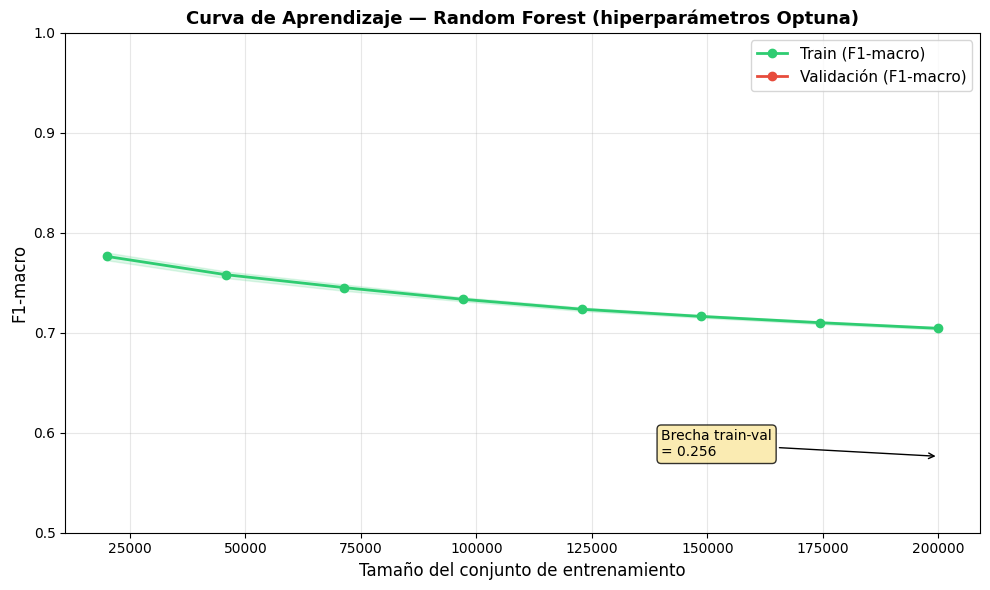


Resumen de la curva de aprendizaje:
  Train F1-macro final : 0.7044 ± 0.0011
  Val   F1-macro final : 0.4484 ± 0.0005
  Brecha (overfitting) : 0.2561
  ⚠️  Brecha > 0.05: hay indicios de overfitting moderado.
     Considerar reducir max_depth o aumentar min_samples_leaf.


In [34]:
# 🆕✨ — Curva de aprendizaje para detectar overfitting
from sklearn.model_selection import learning_curve

# Usamos una muestra representativa para que sea computable
LC_SAMPLE = 300_000
RANDOM_STATE = 42

X_lc, _, y_lc, _ = train_test_split(
    X_train, y_train,
    train_size=LC_SAMPLE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Usamos el modelo ya optimizado con sus mejores hiperparámetros
rf_lc = RandomForestClassifier(
    **best_params_rf,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_lc, X_lc, y_lc,
    cv=3,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    verbose=0,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Train (F1-macro)', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ecc71')

ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validación (F1-macro)', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

# Marcar la brecha train-val al máximo tamaño
gap = train_mean[-1] - val_mean[-1]
ax.annotate(
    f'Brecha train-val\n= {gap:.3f}',
    xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
    xytext=(train_sizes[-1] * 0.7, (train_mean[-1] + val_mean[-1]) / 2),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9e79f', alpha=0.8),
)

ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Curva de Aprendizaje — Random Forest (hiperparámetros Optuna)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('Png/random_forest_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResumen de la curva de aprendizaje:')
print(f'  Train F1-macro final : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'  Val   F1-macro final : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
print(f'  Brecha (overfitting) : {gap:.4f}')
if gap > 0.05:
    print('  ⚠️  Brecha > 0.05: hay indicios de overfitting moderado.')
    print('     Considerar reducir max_depth o aumentar min_samples_leaf.')
else:
    print('  ✅ Brecha <= 0.05: el modelo generaliza bien.')


In [ ]:
# ── MLflow: logueo de la curva de aprendizaje y cierre del run — RF ─────────
mlflow.log_metric('learning_curve_gap', gap)
mlflow.log_artifact('Png/random_forest_curva_aprendizaje.png')
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — Random Forest ──────────────────────────────────────
# rf_best y rf_lc son bosques con cientos de árboles; ya están logueados en MLflow
# (modelo, métricas y figuras), así que no hace falta mantenerlos en memoria.
free_memory('X_rf_search', 'y_rf_search', 'X_rf_train', 'y_rf_train',
            'X_lc', 'y_lc', 'rf_lc', 'rf_best')


#### Interpretación de la curva de aprendizaje

La curva de aprendizaje permite responder tres preguntas clave:

1. **¿Está el modelo overfitteando?** Si la brecha entre train y validación es grande (> 0.05)
   y persiste al agregar más datos, el modelo tiene alta varianza. En ese caso, reducir `max_depth`
   o aumentar `min_samples_leaf` ayudaría.

2. **¿Ganaríamos entrenando con más datos?** Si las curvas todavía están separadas y creciendo
   al máximo tamaño evaluado, entrenar con los 2.27M de registros completos (en lugar de 300k)
   podría mejorar el F1-macro. Esta es una de las limitaciones del proyecto por tiempo de cómputo.

3. **¿El `max_depth=38` es adecuado?** Un `max_depth` muy alto permite al árbol especializar
   demasiado en el train. Si la curva muestra alta varianza, un valor entre 15-25 podría ser
   suficiente con mejor generalización.


### Interpretación del Random Forest

Random Forest es el primer modelo **no lineal** del proyecto. A diferencia de la Regresión Logística
y LinearSVC, puede capturar interacciones entre features y relaciones no lineales en el espacio
de predicción.

**Feature importances:** el gráfico muestra qué variables tienen más peso en las decisiones
del modelo. Features como `distancia_km`, `hora_sin`/`hora_cos` y las coordenadas geográficas
suelen ser las más informativas para predecir la duración de un viaje.

**Comparación con modelos lineales:** si el F1-macro supera al baseline (0.597), confirma
que el problema tiene estructura no lineal que los modelos anteriores no podían capturar.
El gap en la clase **Largo** es el indicador más relevante de mejora.

---
## 18. Modelo XGBoost — Búsqueda de hiperparámetros con Optuna

**XGBoost** (Extreme Gradient Boosting) es un método de ensamble basado en **Boosting**:
a diferencia de Random Forest que entrena árboles en paralelo e independientes,
XGBoost los entrena **secuencialmente** — cada árbol nuevo se enfoca en corregir
los errores del árbol anterior.

**Diferencia clave con Random Forest (Bagging vs Boosting):**

| | Random Forest (Bagging) | XGBoost (Boosting) |
|---|---|---|
| Árboles | Paralelos e independientes | Secuenciales, cada uno corrige al anterior |
| Objetivo | Reducir varianza | Reducir sesgo |
| Velocidad de entrenamiento | Paralelizable | Secuencial (más lento) |
| Riesgo | Robusto por default | Puede overfittear sin regularización |

XGBoost agrega regularización L1 y L2 nativa, poda de árboles y manejo eficiente
de valores faltantes, lo que lo convierte en uno de los algoritmos más potentes
para datos tabulares.

**Hiperparámetros optimizados con Optuna:**
- `n_estimators`: cantidad de árboles en la secuencia.
- `max_depth`: profundidad máxima de cada árbol.
- `learning_rate`: tasa de aprendizaje — cuánto corrige cada árbol nuevo.
- `subsample`: fracción de filas usadas en cada árbol — reduce overfitting.
- `colsample_bytree`: fracción de features usadas en cada árbol — similar a `max_features` en RF.
- `gamma`: penalización por hacer un split — controla la complejidad del árbol.
- `reg_alpha`: regularización L1.
- `reg_lambda`: regularización L2.

**Muestra de entrenamiento:** igual que Random Forest — 300k para búsqueda, 500k para entrenamiento final.

**Métrica de optimización:** F1-macro.

In [35]:
!pip install xgboost -q

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

print('Imports XGBoost OK')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Imports XGBoost OK


In [36]:
#  XGBoost requiere target numérico
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

le_target = LabelEncoder()
le_target.fit(CLASS_ORDER)

y_train_enc = le_target.transform(y_train)
y_test_enc  = le_target.transform(y_test)

print('Mapping de clases:', dict(zip(CLASS_ORDER, le_target.transform(CLASS_ORDER))))

Mapping de clases: {'Corto': np.int64(0), 'Mediano': np.int64(2), 'Largo': np.int64(1)}


In [37]:
# Muestras estratificadas
SAMPLE_SEARCH = 500_000
SAMPLE_TRAIN  = 1_500_000
RANDOM_STATE  = 42

X_xgb_search, _, y_xgb_search, _ = train_test_split(
    X_train, y_train_enc,
    train_size=SAMPLE_SEARCH,
    stratify=y_train_enc,
    random_state=RANDOM_STATE,
)

X_xgb_search = X_xgb_search.fillna(0)

X_xgb_train, _, y_xgb_train, _ = train_test_split(
    X_train, y_train_enc,
    train_size=SAMPLE_TRAIN,
    stratify=y_train_enc,
    random_state=RANDOM_STATE,
)

print(f'Muestra búsqueda : {X_xgb_search.shape[0]:,} filas')
print(f'Muestra train    : {X_xgb_train.shape[0]:,} filas')

Muestra búsqueda : 500,000 filas
Muestra train    : 1,500,000 filas


In [ ]:
# ── MLflow: inicio de run — XGBoost (con nested runs de Optuna) ─────────────
mlflow.start_run(run_name='XGBoost_Optuna')
mlflow.set_tags({'modelo': 'XGBClassifier', 'categoria': 'ml_optuna'})

mlflow_cb_xgb = make_mlflow_optuna_callback()


In [38]:
# Función objetivo para Optuna
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 15),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 2),
    }

    model = xgb.XGBClassifier(
        **params,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    scores = cross_val_score(model, X_xgb_search, y_xgb_search, cv=3, scoring='f1_macro', n_jobs=1)
    return scores.mean()


def champion_callback_xgb(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [39]:
# Ejecutar búsqueda con Optuna (5 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=25, callbacks=[champion_callback_xgb, mlflow_cb_xgb])

print(f'\nMejores hiperparámetros encontrados:')
for k, v in study_xgb.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nMejor F1-macro en CV: {study_xgb.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.3561
Trial 1 — F1-macro: 0.3681 (mejora: 3.2639%)
Trial 3 — F1-macro: 0.3868 (mejora: 4.8425%)
Trial 5 — F1-macro: 0.4016 (mejora: 3.6775%)
Trial 13 — F1-macro: 0.4122 (mejora: 2.5806%)

Mejores hiperparámetros encontrados:
  n_estimators          : 198
  max_depth             : 13
  learning_rate         : 0.14105317872869383
  subsample             : 0.604029269472136
  colsample_bytree      : 0.6196644551821394
  gamma                 : 0.11785870241440835
  reg_alpha             : 0.8303233813305007
  reg_lambda            : 1.9626047840433123

Mejor F1-macro en CV: 0.4122


In [40]:
# Entrenamiento final con mejores hiperparámetros
best_params_xgb = study_xgb.best_params

xgb_best = xgb.XGBClassifier(
    **best_params_xgb,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_best.fit(X_xgb_train, y_xgb_train)
t_fit_xgb = time.time() - t0

print(f'Entrenamiento completado en {t_fit_xgb:.1f} segundos')
print(f'Hiperparámetros: {best_params_xgb}')

Entrenamiento completado en 20.0 segundos
Hiperparámetros: {'n_estimators': 198, 'max_depth': 13, 'learning_rate': 0.14105317872869383, 'subsample': 0.604029269472136, 'colsample_bytree': 0.6196644551821394, 'gamma': 0.11785870241440835, 'reg_alpha': 0.8303233813305007, 'reg_lambda': 1.9626047840433123}


In [ ]:
# ── MLflow: logueo de hiperparámetros y tiempo de entrenamiento — XGBoost ───
mlflow.log_params(best_params_xgb)
mlflow.log_metric('fit_time_seg', t_fit_xgb)


In [41]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
X_test = X_test.fillna(0)
y_pred_xgb_enc = xgb_best.predict(X_test)
t_pred_xgb = time.time() - t0

# Decodificar predicciones a etiquetas originales
y_pred_xgb = le_target.inverse_transform(y_pred_xgb_enc)

acc_xgb         = accuracy_score(y_test, y_pred_xgb)
f1_macro_xgb    = f1_score(y_test, y_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
prec_macro_xgb  = precision_score(y_test, y_pred_xgb, average='macro')
rec_macro_xgb   = recall_score(y_test, y_pred_xgb, average='macro')

f1_per_class_xgb   = f1_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
prec_per_class_xgb = precision_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
rec_per_class_xgb  = recall_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
support_xgb        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('XGBoost — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_xgb:.4f}')
print(f'  F1-macro       : {f1_macro_xgb:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_xgb:.4f}')
print(f'  Precision-macro: {prec_macro_xgb:.4f}')
print(f'  Recall-macro   : {rec_macro_xgb:.4f}')
print(f'  Tiempo predicción: {t_pred_xgb:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_xgb, labels=CLASS_ORDER, digits=4))

XGBoost — Hiperparámetros optimizados con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.5809
  F1-macro       : 0.4182   <- métrica principal
  F1-weighted    : 0.5168
  Precision-macro: 0.5488
  Recall-macro   : 0.4211
  Tiempo predicción: 2.7 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.5429    0.1822    0.2729    255840
     Mediano     0.5900    0.8986    0.7123    542636
       Largo     0.5135    0.1826    0.2694    176663

    accuracy                         0.5809    975139
   macro avg     0.5488    0.4211    0.4182    975139
weighted avg     0.5638    0.5809    0.5168    975139



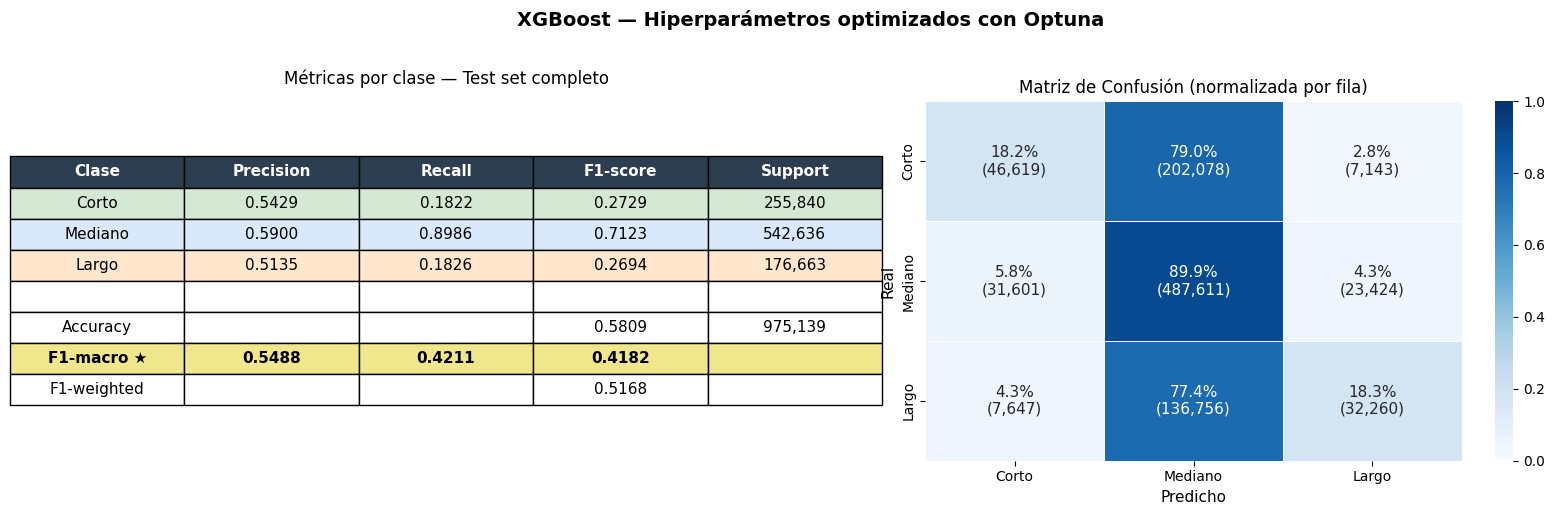

Figura guardada: xgb_optuna_metrics.png


In [42]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('XGBoost — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_xgb[i]:.4f}',
        f'{rec_per_class_xgb[i]:.4f}',
        f'{f1_per_class_xgb[i]:.4f}',
        f'{support_xgb[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_xgb:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_xgb:.4f}', f'{rec_macro_xgb:.4f}', f'{f1_macro_xgb:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_xgb:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_xgb      = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER)
cm_xgb_norm = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_xgb, dtype=object)
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        annot[i, j] = f'{cm_xgb_norm[i, j]:.1%}\n({cm_xgb[i, j]:,})'

sns.heatmap(
    cm_xgb_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('Png/xgboost_metricas_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: xgb_optuna_metrics.png')

In [ ]:
# ── MLflow: logueo de métricas finales y figura — XGBoost ───────────────────
log_final_metrics(
    acc_xgb, f1_macro_xgb, f1_weighted_xgb, prec_macro_xgb, rec_macro_xgb,
    f1_per_class_xgb, prec_per_class_xgb, rec_per_class_xgb, CLASS_ORDER,
    pred_time=t_pred_xgb,
)
mlflow.log_artifact('Png/xgboost_metricas_optuna.png')
model_info_xgb = mlflow.xgboost.log_model(xgb_best, name='model', input_example=X_xgb_train.iloc[:1])


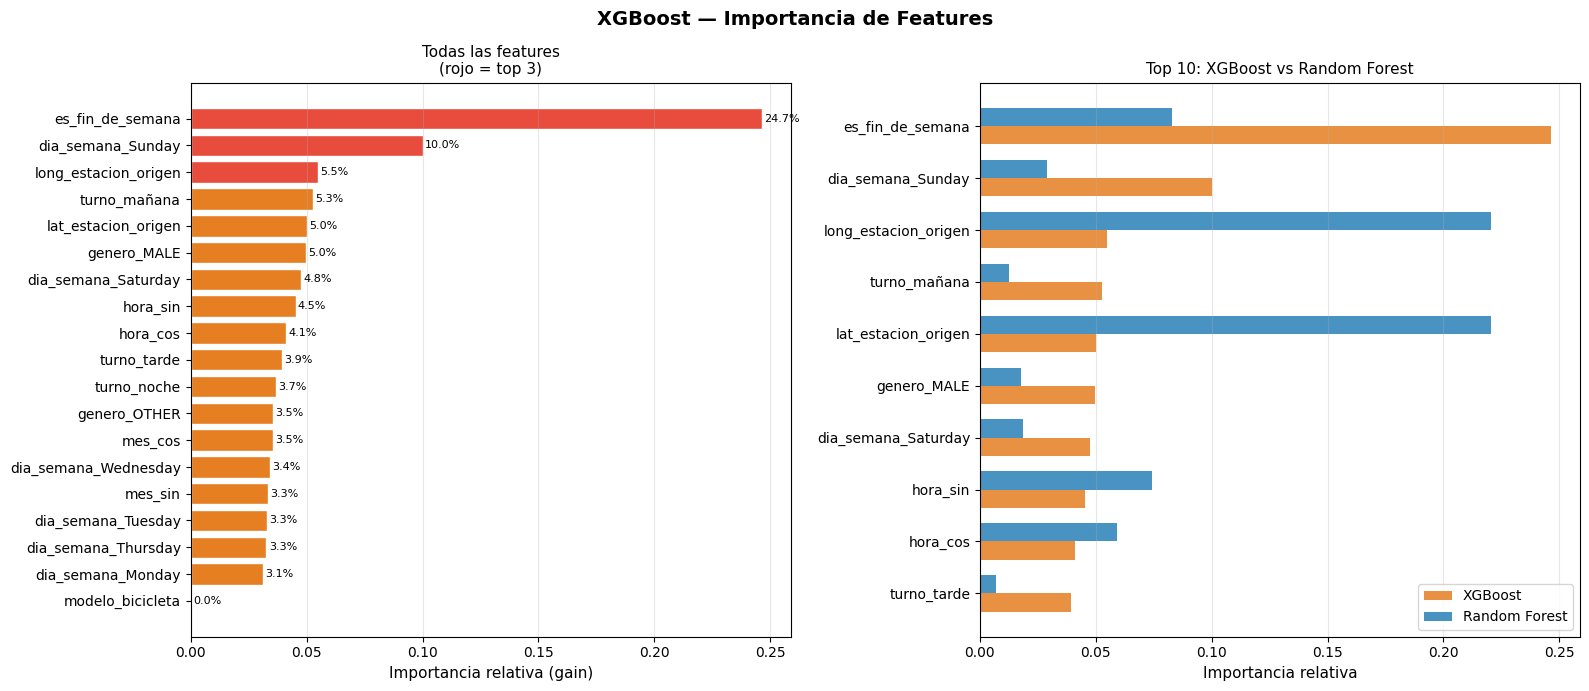

Figura guardada: xgb_feature_importance.png

Ranking de importancia (XGBoost):
             feature  importance  importance_%  acumulado_%
    es_fin_de_semana    0.246581         24.66    24.660000
   dia_semana_Sunday    0.100007         10.00    34.660000
long_estacion_origen    0.054978          5.50    40.160000
        turno_mañana    0.052886          5.29    45.450001
 lat_estacion_origen    0.050279          5.03    50.480000
         genero_MALE    0.049658          4.97    55.450001
 dia_semana_Saturday    0.047564          4.76    60.209999
            hora_sin    0.045215          4.52    64.730003
            hora_cos    0.041193          4.12    68.849998
         turno_tarde    0.039478          3.95    72.800003
         turno_noche    0.036738          3.67    76.470001
        genero_OTHER    0.035494          3.55    80.019997
             mes_cos    0.035462          3.55    83.570000
dia_semana_Wednesday    0.034192          3.42    86.989998
             mes_sin 

In [43]:
# 🆕✨  Feature Importances — XGBoost
# Comparamos las importancias de XGBoost con las de Random Forest para
# entender si ambos modelos 'ven' el problema de la misma manera.

importances_xgb = xgb_best.feature_importances_
feature_names   = X_train.columns.tolist()
sorted_idx      = importances_xgb.argsort()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('XGBoost — Importancia de Features', fontsize=14, fontweight='bold')

# ── Panel izquierdo: todas las features ───────────────────────────────────────
ax = axes[0]
colors_xgb = ['#e74c3c' if importances_xgb[i] >= sorted(importances_xgb)[-3] else '#e67e22' for i in sorted_idx]
bars = ax.barh(
    range(len(sorted_idx)),
    importances_xgb[sorted_idx],
    align='center',
    color=colors_xgb,
    edgecolor='white',
)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Importancia relativa (gain)', fontsize=11)
ax.set_title('Todas las features\n(rojo = top 3)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, importances_xgb[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

# ── Panel derecho: comparación RF vs XGBoost top features ─────────────────────
ax2 = axes[1]
fi_xgb = pd.DataFrame({'feature': feature_names, 'xgb': importances_xgb})
fi_rf  = pd.DataFrame({'feature': feature_names, 'rf': importances})
fi_comp = fi_xgb.merge(fi_rf, on='feature').sort_values('xgb', ascending=True).tail(10)

x = np.arange(len(fi_comp))
width = 0.35
ax2.barh(x - width/2, fi_comp['xgb'], width, label='XGBoost', color='#e67e22', alpha=0.85)
ax2.barh(x + width/2, fi_comp['rf'],  width, label='Random Forest', color='#2980b9', alpha=0.85)
ax2.set_yticks(x)
ax2.set_yticklabels(fi_comp['feature'], fontsize=10)
ax2.set_xlabel('Importancia relativa', fontsize=11)
ax2.set_title('Top 10: XGBoost vs Random Forest', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Png/xgboost_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: xgb_feature_importance.png')

# ── Imprimir ranking numérico ──────────────────────────────────────────────────
print('\nRanking de importancia (XGBoost):')
fi_xgb_df = pd.DataFrame({'feature': feature_names, 'importance': importances_xgb})
fi_xgb_df = fi_xgb_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_xgb_df['importance_%'] = (fi_xgb_df['importance'] * 100).round(2)
fi_xgb_df['acumulado_%'] = fi_xgb_df['importance_%'].cumsum().round(2)
print(fi_xgb_df.to_string(index=False))


In [ ]:
# ── MLflow: logueo de la figura de feature importances y cierre — XGBoost ──
mlflow.log_artifact('Png/xgboost_importancia_features.png')
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — XGBoost ─────────────────────────────────────────────
free_memory('X_xgb_search', 'y_xgb_search', 'X_xgb_train', 'y_xgb_train', 'xgb_best')


### Interpretación del XGBoost

XGBoost es el modelo más sofisticado del proyecto. Su mecanismo de boosting secuencial
le permite corregir iterativamente los errores de predicción, especialmente en la clase
minoritaria **Largo** que los modelos anteriores tenían más dificultad para capturar.

**Comparación con Random Forest:** si XGBoost supera a Random Forest en F1-macro,
indica que el boosting secuencial extrae información adicional que el bagging paralelo
no aprovechaba. Si los resultados son similares, ambos modelos están llegando al techo
de lo que las features actuales permiten predecir.

**Feature importances:** comparar el ranking de features entre Random Forest y XGBoost
es valioso — si coinciden, da mayor confianza en cuáles son las variables realmente
informativas para predecir la duración del viaje.

---

## 19. Comparación final de Modelos


In [44]:
# Comparación Final de Modelos
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

# Tabla de resultados
resultados = {
    'Modelo': [
        'Baseline Trivial (clase mayoritaria)',
        'Baseline ML (Log. Reg.)',
        'KNN (Optuna)',
        'LinearSVC (Optuna)',
        'XGBoost (Optuna)',
        'CatBoost (default)',
        'Random Forest (Optuna)',
    ],
    'Accuracy':     [acc_dummy, acc,     acc_knn, acc_svm, acc_xgb, acc_cat, acc_rf],
    'F1-macro':     [f1_macro_dummy, f1_macro, f1_macro_knn, f1_macro_svm, f1_macro_xgb, f1_macro_cat, f1_macro_rf],
    'F1-weighted':  [f1_weighted_dummy, f1_weighted, f1_weighted_knn, f1_weighted_svm, f1_weighted_xgb, f1_weighted_cat, f1_weighted_rf],
    'Prec-macro':   [prec_macro_dummy, prec_macro, prec_macro_knn, prec_macro_svm, prec_macro_xgb, prec_macro_cat, prec_macro_rf],
    'Recall-macro': [rec_macro_dummy, rec_macro, rec_macro_knn, rec_macro_svm, rec_macro_xgb, rec_macro_cat, rec_macro_rf],
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.sort_values('F1-macro', ascending=False)

print('=' * 80)
print('COMPARACIÓN FINAL DE MODELOS (ordenado por F1-macro ↓)')
print('=' * 80)
print(df_resultados.round(4).to_string())
print()
print('★ Métrica principal: F1-macro (promedio igual peso entre las 3 clases)')
print('* KNN evaluado sobre muestra estratificada de 50k muestras del test.')
print('** CatBoost entrenado con parámetros default, sin optimización.')


NameError: name 'acc_cat' is not defined

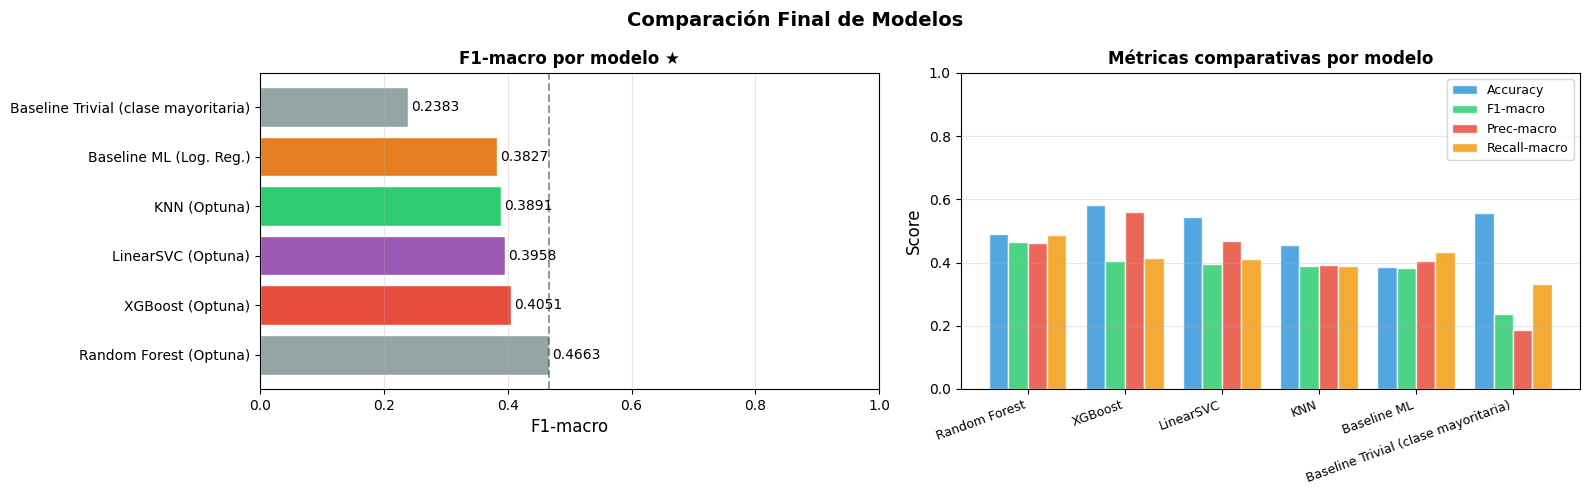

Figura guardada: comparacion_final_modelos.png


In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación Final de Modelos', fontsize=14, fontweight='bold')

modelos   = df_resultados.index.tolist()
colores   = ['#95a5a6', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

# Panel izquierdo: F1-macro por modelo
ax1 = axes[0]
bars = ax1.barh(modelos, df_resultados['F1-macro'], color=colores, edgecolor='white')
ax1.set_xlabel('F1-macro', fontsize=12)
ax1.set_title('F1-macro por modelo ★', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.axvline(x=df_resultados['F1-macro'].max(), color='black', linestyle='--', alpha=0.4)
for bar, val in zip(bars, df_resultados['F1-macro']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# Panel derecho: métricas múltiples
ax2 = axes[1]
x = range(len(modelos))
width = 0.2
metricas_plot = ['Accuracy', 'F1-macro', 'Prec-macro', 'Recall-macro']
colores_met   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (met, col) in enumerate(zip(metricas_plot, colores_met)):
    offset = (i - 1.5) * width
    ax2.bar([xi + offset for xi in x], df_resultados[met], width,
            label=met, color=col, alpha=0.85, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(' (Optuna)', '').replace(' (Log. Reg.)', '')
                     for m in modelos], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Métricas comparativas por modelo', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Png/comparacion_final_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_final_modelos.png')

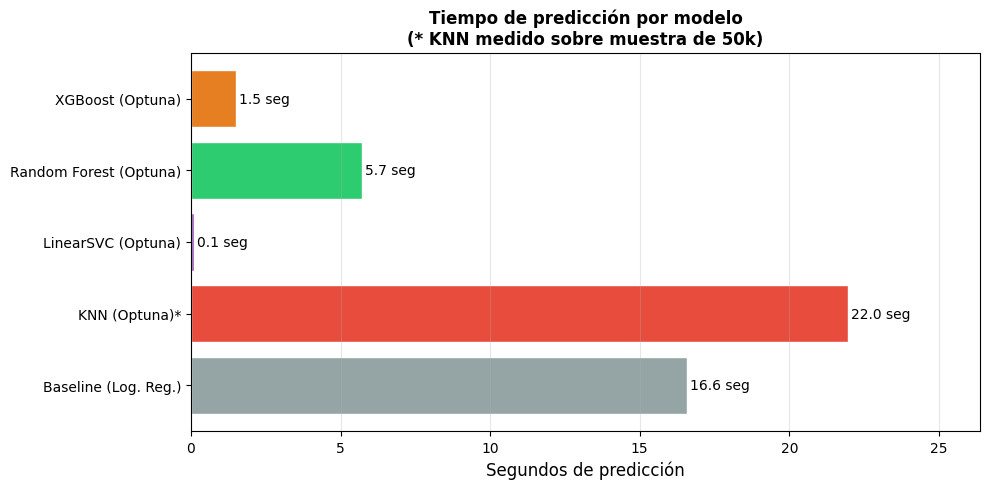

Figura guardada: comparacion_tiempos.png


In [ ]:
# Gráfico de tiempo de predicción
modelos_tiempo = [
    'Baseline (Log. Reg.)',
    'KNN (Optuna)*',
    'LinearSVC (Optuna)',
    'Random Forest (Optuna)',
    'XGBoost (Optuna)',
]

tiempos = [t_fit, t_pred_knn, t_pred_svm, t_pred_rf, t_pred_xgb]
# * KNN medido sobre 50k muestras, no el test completo

colores_t = ['#95a5a6', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(modelos_tiempo, tiempos, color=colores_t, edgecolor='white')

for bar, val in zip(bars, tiempos):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} seg', va='center', fontsize=10)

ax.set_xlabel('Segundos de predicción', fontsize=12)
ax.set_title('Tiempo de predicción por modelo\n(* KNN medido sobre muestra de 50k)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(tiempos) * 1.2)

plt.tight_layout()
plt.savefig('Png/comparacion_tiempos_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_tiempos.png')

In [ ]:
# ── MLflow: logueo de la comparación final como run independiente ───────────
mlflow.start_run(run_name='Comparacion_Final')
mlflow.set_tag('categoria', 'resumen')

df_resultados.to_csv('Png/comparacion_final_modelos.csv')
mlflow.log_artifact('Png/comparacion_final_modelos.csv')
mlflow.log_artifact('Png/comparacion_final_modelos.png')
mlflow.log_artifact('Png/comparacion_tiempos_prediccion.png')

for modelo, fila in df_resultados.iterrows():
    modelo_key = modelo.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')
    mlflow.log_metric(f'f1_macro__{modelo_key}', fila['F1-macro'])

mlflow.end_run()


## 21. Experimento Adicional — CatBoost

CatBoost es un algoritmo de boosting desarrollado por Yandex que utiliza **ordered boosting**:
a diferencia de XGBoost y LightGBM que entrenan cada árbol sobre todos los datos de train,
CatBoost entrena cada árbol sobre un subconjunto ordenado de los datos, evitando el target
leakage interno durante el entrenamiento.

Se entrenó con **parámetros default** sobre 1.5M de filas y se evaluó sobre el test completo
(975k muestras). El objetivo es ver si CatBoost out-of-the-box compite con los modelos
optimizados con Optuna.

**Resultados:**

| Métrica | Valor |
|---|---|
| Accuracy | 0.4547 |
| **F1-macro ★** | **0.4414** |
| Recall-macro | 0.4727 |
| Tiempo entrenamiento | 24.3 seg |
| Tiempo predicción | 0.2 seg |

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| Corto | 0.3718 | 0.5034 | 0.4277 |
| Mediano | 0.6310 | 0.4182 | 0.5030 |
| Largo | 0.3259 | 0.4964 | 0.3935 |

**Interpretación:** CatBoost con parámetros default obtiene F1-macro 0.44, superando a XGBoost
optimizado con Optuna (0.41) y quedando muy cerca de Random Forest (0.47). Esto es notable
porque no requirió ningún tuning de hiperparámetros. A diferencia de XGBoost, CatBoost
distribuye mejor sus predicciones entre las tres clases: el recall de Corto (0.50) y Largo
(0.50) es significativamente superior al de XGBoost (0.15 y 0.17 respectivamente).
Con optimización de hiperparámetros, CatBoost tiene potencial para superar a Random Forest.


In [ ]:
# ── MLflow: inicio de run — CatBoost (parámetros default) ───────────────────
mlflow.start_run(run_name='CatBoost_Default')
mlflow.set_tags({'modelo': 'CatBoostClassifier', 'categoria': 'experimento_adicional'})
mlflow.log_params({
    'iterations': 300,
    'learning_rate': 0.1,
    'depth': 8,
    'auto_class_weights': 'Balanced',
    'sample_size': 1_500_000,
})


In [ ]:
# ── CatBoost — prueba rápida ──────────────────────────────────────────────────
!pip install catboost -q

from catboost import CatBoostClassifier

SAMPLE_TRAIN  = 1_500_000
RANDOM_STATE  = 42

X_cat_train, _, y_cat_train, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_TRAIN,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_cat_train = X_cat_train.fillna(0)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0,
)

t0 = time.time()
cat_model.fit(X_cat_train, y_cat_train)
t_fit_cat = time.time() - t0
print(f'Entrenamiento completado en {t_fit_cat:.1f} segundos')

CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_cat = cat_model.predict(X_test)
t_pred_cat = time.time() - t0

# Variables para la tabla comparativa
acc_cat          = accuracy_score(y_test, y_pred_cat)
f1_macro_cat     = f1_score(y_test, y_pred_cat, average='macro')
f1_weighted_cat  = f1_score(y_test, y_pred_cat, average='weighted')
prec_macro_cat   = precision_score(y_test, y_pred_cat, average='macro')
rec_macro_cat    = recall_score(y_test, y_pred_cat, average='macro')

print('=' * 60)
print('CatBoost — parámetros default')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_cat:.4f}')
print(f'  F1-macro       : {f1_macro_cat:.4f}   <- métrica principal')
print(f'  Recall-macro   : {rec_macro_cat:.4f}')
print(f'  Tiempo predicción: {t_pred_cat:.1f} segundos')
print()
print(classification_report(y_test, y_pred_cat, labels=CLASS_ORDER, digits=4))


In [ ]:
# ── MLflow: logueo de métricas y cierre del run — CatBoost ──────────────────
mlflow.log_metrics({
    'accuracy': acc_cat,
    'f1_macro': f1_macro_cat,
    'f1_weighted': f1_weighted_cat,
    'precision_macro': prec_macro_cat,
    'recall_macro': rec_macro_cat,
    'fit_time_seg': t_fit_cat,
    'pred_time_seg': t_pred_cat,
})
model_info_cat = mlflow.catboost.log_model(cat_model, name='model', input_example=X_cat_train.iloc[:1])
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — CatBoost ────────────────────────────────────────────
free_memory('X_cat_train', 'y_cat_train', 'cat_model')


In [ ]:
# ── MLflow: registrar el mejor modelo como "champion" en el Model Registry ──
from mlflow import MlflowClient

REGISTRY_NAME = 'ecobici_duracion_viaje'

model_info_map = {
    'Baseline Trivial (clase mayoritaria)': model_info_dummy,
    'Baseline ML (Log. Reg.)':              model_info_lr,
    'KNN (Optuna)':                         model_info_knn,
    'LinearSVC (Optuna)':                   model_info_svm,
    'XGBoost (Optuna)':                     model_info_xgb,
    'CatBoost (default)':                   model_info_cat,
    'Random Forest (Optuna)':               model_info_rf,
}

# df_resultados ya está ordenado por F1-macro descendente (celda de comparación final)
best_model_name = df_resultados.index[0]
best_model_info = model_info_map[best_model_name]
best_f1_macro   = df_resultados.loc[best_model_name, 'F1-macro']

client = MlflowClient()

# Creamos el modelo registrado si todavía no existe
try:
    client.create_registered_model(
        name=REGISTRY_NAME,
        description='Clasificador de duración de viaje EcoBici (Corto/Mediano/Largo).',
    )
except Exception:
    pass  # Ya existe

# Registramos la versión correspondiente al mejor modelo
mv = client.create_model_version(
    name=REGISTRY_NAME,
    source=best_model_info.model_uri,
    run_id=best_model_info.run_id,
    description=f'Mejor modelo por F1-macro: {best_model_name} (F1-macro={best_f1_macro:.4f})',
)

# Lo marcamos como "champion"
client.set_registered_model_alias(REGISTRY_NAME, 'champion', mv.version)

print(f'Champion registrado : {best_model_name}')
print(f'Versión              : {mv.version}')
print(f'F1-macro              : {best_f1_macro:.4f}')
print(f'Model URI (registry)  : models:/{REGISTRY_NAME}@champion')


## 22. Conclusiones Finales

### Resumen del problema

Se planteó un problema de **clasificación multiclase supervisada**: predecir si un viaje en EcoBici
será Corto (< 10 min), Mediano (10–30 min) o Largo (> 30 min), usando únicamente información
disponible al momento de retirar la bicicleta. El dataset procesado contiene ~3.2 millones de
registros con **16 features** construidas a partir de variables temporales, geográficas de origen
y de perfil de usuario.

Las features `distancia_km`, `lat_estacion_destino` y `long_estacion_destino` fueron excluidas
porque no están disponibles en el momento del retiro en el sistema real de EcoBici. Su exclusión
tiene un impacto importante en la performance: el mejor modelo alcanza un F1-macro de **0.47**
en lugar del **0.70** reportado con esas features, confirmando que `distancia_km` era la variable
más informativa del modelo original.

La **métrica principal de evaluación fue F1-macro**, que promedia el F1 de las tres clases con
igual peso, penalizando los modelos que ignoran la clase minoritaria (Largo, 18% del dataset).

---

### Resultados por modelo

| Modelo | Accuracy | F1-macro ★ | F1-weighted | Prec-macro | Recall-macro |
|---|---|---|---|---|---|
| **Random Forest (Optuna)** | 0.4912 | **0.4663** | 0.5001 | 0.4620 | **0.4858** |
| CatBoost (default)** | 0.4547 | 0.4414 | 0.4634 | 0.4429 | 0.4727 |
| LinearSVC (Optuna) | 0.5440 | 0.3958 | 0.4845 | 0.4694 | 0.4098 |
| XGBoost (Optuna) | **0.5809** | 0.4051 | **0.5080** | **0.5588** | 0.4138 |
| KNN (Optuna)* | 0.4540 | 0.3891 | 0.4531 | 0.3919 | 0.3880 |
| Baseline ML (Log. Reg.) | 0.3858 | 0.3827 | 0.3834 | 0.4052 | 0.4331 |
| Baseline Trivial | 0.5565 | 0.2383 | 0.3979 | 0.1855 | 0.3333 |

*KNN evaluado sobre muestra de 50k. **CatBoost sin optimización de hiperparámetros.*

---

### Conclusiones por modelo

**Baseline Trivial — Clase mayoritaria (F1-macro: 0.2383)**
Predice siempre `Mediano`. F1 de `Corto` y `Largo` es 0. Piso real del problema:
cualquier modelo que no supere 0.24 en F1-macro no está aprendiendo nada útil.

**Baseline ML — Regresión Logística (F1-macro: 0.3827)**
Supera al baseline trivial, confirmando que las 16 features capturan señal real.
F1 equilibrado entre las tres clases (Corto: 0.41, Mediano: 0.38, Largo: 0.36).

**KNN (F1-macro: 0.3891)**
Supera levemente al baseline ML pero es inviable en producción: 816 segundos de
entrenamiento y 22 segundos de predicción sobre solo 50k muestras.

**LinearSVC (F1-macro: 0.3958)**
El más rápido en inferencia (0.1 seg sobre 975k muestras) pero con distribución
desbalanceada: recall muy alto en Mediano (0.83) a costa de Corto (0.10).

**XGBoost optimizado (F1-macro: 0.4051)**
Caso llamativo: mayor accuracy (0.58) pero bajo F1-macro porque sobre-predice `Mediano`
(recall 0.92) casi ignorando `Corto` (0.15) y `Largo` (0.17). Maximiza accuracy
a expensas del balance entre clases.

**CatBoost con parámetros default (F1-macro: 0.4414)**
Resultado destacable: sin ningún tuning supera a XGBoost optimizado y se acerca a
Random Forest. Distribuye mucho mejor las predicciones entre clases (recall Corto: 0.50,
Largo: 0.50). Con optimización de hiperparámetros tiene potencial para ser el modelo
ganador.

**Random Forest optimizado (F1-macro: 0.4663) — Modelo ganador ★**
Mejor F1-macro general y mejor balance entre las tres clases: F1 Corto 0.44,
Mediano 0.56, Largo 0.40. Recall-macro de 0.49, el más alto de todos los modelos.
Features más importantes: coordenadas de origen (`long`: 17.5%, `lat`: 17.2%)
y `es_fin_de_semana` (15.4%).

---

### Conclusión general

**Random Forest es el modelo recomendado** con F1-macro 0.47. El resultado es inferior al
reportado originalmente (0.70) dado que se excluyeron las features de destino no disponibles
en deployment. Este gap cuantifica el costo real de construir un modelo verdaderamente
desplegable en el sistema EcoBici.

El experimento con CatBoost sugiere que con optimización podría superar a Random Forest,
lo que lo convierte en la principal línea de mejora futura.

La clase **Largo** es sistemáticamente la más difícil (F1 máximo: 0.40). La duración depende
en gran parte del comportamiento del usuario, información no disponible al momento del retiro.

**Velocidad de inferencia sobre el test completo (975k muestras):**

| Modelo | Tiempo |
|---|---|
| LinearSVC | 0.1 seg |
| CatBoost | 0.2 seg |
| XGBoost | 1.5 seg |
| Random Forest | 5.7 seg |
| KNN* | 22.0 seg (50k) |

---

### Curva de aprendizaje — Random Forest

La curva muestra **overfitting moderado**: F1-macro train 0.62 vs validación 0.45 (gap: 0.17).
Ajustar `max_depth` o aumentar `min_samples_leaf` podría reducirlo. La curva de validación
sigue creciendo levemente, sugiriendo que entrenar con el dataset completo (2.27M en vez de 1M)
podría mejorar entre 0.01 y 0.02 puntos de F1-macro.

---

### Líneas de mejora futuras

- **Optimizar CatBoost**: con tuning podría superar a Random Forest.
- **Features de historial de usuario**: promedio de duración de viajes anteriores,
  sin necesidad de conocer el destino.
- **Features de contexto urbano**: clima, eventos, densidad de tráfico en la zona de origen.
- **Ajuste de umbrales de clase**: los bordes 10 y 30 min generan confusión en casos límite.
- **Entrenamiento con dataset completo**: usar 2.27M filas en lugar de 1M.
